# Loan Approval Prediction

## Problem statement

A lender receives applications containing an applicant's personal, financial and credit details. For each one, a decision has to be made: **approve** or **reject**.

This notebook builds a machine learning system to make that decision.

## Dataset

[Loan Approval Classification Data](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data) — approximately 45,000 synthetic loan applications with 13 input features and one target column.

The data dictionary defines the target as:

> **`loan_status`** — *Loan approval status: 1 = approved; 0 = rejected* — Integer

The 13 features **as supplied in the raw file** fall into three groups:

**Personal:** age, gender, education level, employment experience
**Financial:** annual income, home ownership status, credit score, credit history length
**Loan:** amount requested, purpose (intent), interest rate, loan-to-income ratio, prior default flag

Not all thirteen end up in the model. Section 8 works through which are kept and why.

## How this notebook proceeds

| Section | Purpose |
|---|---|
| 1 | Environment and imports |
| 2 | Load the data and take a first look |
| 3 | Data quality — missing values, dtypes, implausible records |
| 4 | Exploratory data analysis |
| 5 | A first model using every feature, as a reference point |
| 6 | Explaining that model with SHAP |
| 7 | Investigating the feature that dominates it |
| 8 | Feature selection — what to keep, what to drop, and why |
| 9 | System design |
| 10 | Preparing data for Stage 2 |
| 11 | Stage 2 — the final model and its decision threshold |
| 12 | Explaining the final model |
| 13 | Summary |

## Metrics used, and why

The target is imbalanced, which makes **accuracy misleading**. If 78% of applications are rejected, a model that rejects everything scores 78% accuracy while being worthless.

So the metrics reported throughout are:

- **ROC-AUC** — measures how well the model *ranks* applicants by risk, independent of where the approve/reject cutoff is placed. This is the primary metric for comparing models.
- **Precision on the positive class** — of the applicants we approved, what fraction should have been approved. Low precision means risky lending.
- **Recall on the positive class** — of the applicants who should have been approved, what fraction did we catch. Low recall means turning away good business.
- **F1** — the harmonic mean of precision and recall, useful as a single number when both matter.
- **Confusion matrix** — the raw counts, so false positives and false negatives can be read directly.

## One methodological rule, stated up front

**The decision threshold is chosen using a validation set, and final performance is reported on a separate test set that is never used for any decision.**

This matters more than it sounds. The threshold — the probability above which we approve — is something we *choose*. If we pick the threshold that produces the best F1 on the test set and then report that F1, the number is no longer an estimate of performance on unseen applicants. It is fitted to the test set. The three-way split introduced in Section 5.1 exists specifically to prevent this.

> **To run this notebook:** execute cells top to bottom. Requires `pandas`, `numpy`, `scikit-learn`, `xgboost`, `shap`, `matplotlib`, `seaborn`. The dataset is expected at `../data/raw/loan_data.csv`.

---

## 1. Imports and configuration

Everything needed is imported here so there are no surprise dependencies partway through.

In [136]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
)

# Explainability
import shap
import scipy.sparse as sp

warnings.filterwarnings("ignore")

# A fixed seed everywhere, so every split and every model is reproducible.
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported.")

Libraries imported.


In [137]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
TARGET = "loan_status"

# Applications recording an age above this are not credible -- justified in
# Section 3.3, where the offending records are printed.
MAX_PLAUSIBLE_AGE = 90

print(f"Target column:     {TARGET}")
print(f"Max plausible age: {MAX_PLAUSIBLE_AGE}")

Target column:     loan_status
Max plausible age: 90


---

## 2. Loading the data

The CSV sits one directory up from `notebooks/`, in `data/raw/`.

In [138]:
df = pd.read_csv("../data/raw/loan_data.csv")

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows:    44,719
Columns: 14


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,25,male,Master,210903,4,MORTGAGE,8000,HOMEIMPROVEMENT,7.90,0.04,2,588,Yes,0
1,22,male,Associate,210555,0,MORTGAGE,18000,EDUCATION,11.01,0.09,2,652,No,0
2,23,male,Bachelor,210937,0,MORTGAGE,21000,PERSONAL,11.99,0.10,3,620,Yes,0
3,23,male,High School,19062,2,OWN,4000,DEBTCONSOLIDATION,13.98,0.21,4,667,No,1
4,23,female,Associate,18926,0,OWN,4600,VENTURE,10.99,0.24,2,688,No,1


### 2.1 Column types

Before anything else, we need to know which columns are numeric and which are categorical, because they need different handling — categorical columns must be encoded before a model can use them.

In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44719 entries, 0 to 44718
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44719 non-null  int64  
 1   person_gender                   44719 non-null  str    
 2   person_education                44719 non-null  str    
 3   person_income                   44719 non-null  int64  
 4   person_emp_exp                  44719 non-null  int64  
 5   person_home_ownership           44719 non-null  str    
 6   loan_amnt                       44719 non-null  int64  
 7   loan_intent                     44719 non-null  str    
 8   loan_int_rate                   44719 non-null  float64
 9   loan_percent_income             44719 non-null  float64
 10  cb_person_cred_hist_length      44719 non-null  int64  
 11  credit_score                    44719 non-null  int64  
 12  previous_loan_defaults_on_file  44719 non-n

Seven integer columns, two float columns, and five text columns. The five text columns are the categorical features: gender, education, home ownership, loan intent, and the prior-default flag.

`loan_status` is an integer taking values 0 and 1 — the binary target.

### 2.2 Summary statistics

`describe()` gives the distribution of every numeric column. This is where data problems usually announce themselves.

In [140]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,44719.0,27.783649,6.004701,20.00,24.00,26.00,30.00,144.00
person_income,44719.0,79978.775442,80161.292870,8000.00,47141.50,67006.00,95303.50,7200766.00
person_emp_exp,44719.0,5.428811,6.022323,0.00,1.00,4.00,8.00,124.00
loan_amnt,44719.0,9516.934413,6227.397665,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,44719.0,10.998391,2.976072,5.42,8.59,11.01,12.99,20.00
loan_percent_income,44719.0,0.139225,0.086628,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,44719.0,5.885284,3.884835,2.00,3.00,4.00,8.00,30.00
credit_score,44719.0,632.653391,50.439448,390.00,602.00,640.00,670.00,850.00
loan_status,44719.0,0.219996,0.414248,0.00,0.00,0.00,0.00,1.00


### 2.3 Reading the summary table

Four things stand out, and each one needs a decision.

**`person_age` has a maximum of 144.** No loan applicant is 144 years old. Something is wrong with a small number of records.

**`person_emp_exp` has a maximum of 124** — 124 years of employment experience. Same problem, and probably the same records.

**`person_income` ranges from 8,000 to 7,200,766** with a median of 67,006. The mean (79,979) sits well above the median, which is the signature of a right-skewed distribution with a long tail of high earners. This is not an error — incomes really are distributed this way — but it matters for model choice. Linear models are sensitive to feature scale and skew; tree-based models split on ordering and are indifferent to both.

**The target mean is 0.22.** So roughly 22% of applications in this dataset were approved and 78% rejected. This is the class imbalance that rules out accuracy as a headline metric.

The first two need fixing. The third informs preprocessing. The fourth informs metric choice.

---

## 3. Data quality

### 3.1 Missing values

Any column with missing values needs an imputation strategy, or the rows need dropping. Checking first.

In [141]:
missing = df.isnull().sum()

if missing.any():
    print("Columns with missing values:")
    print(missing[missing > 0])
else:
    print("No missing values in any column.")

print(f"\nTotal cells: {df.size:,}")
print(f"Missing:     {df.isnull().sum().sum():,}")

No missing values in any column.

Total cells: 626,066
Missing:     0


No missing values anywhere. That means no imputation is needed, which simplifies the pipeline considerably.

It is also worth registering as slightly unusual. Real credit application data is almost always incomplete — applicants skip fields, credit bureaus return partial records. A dataset with zero missing values across 44,719 rows and 14 columns is a sign of synthetic generation rather than observed data. That doesn't make it unusable, but it does mean conclusions drawn here describe *this dataset* and shouldn't be presented as facts about real lending.

### 3.2 Duplicate rows

Duplicates inflate apparent dataset size and can leak between train and test splits.

In [142]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes:,}")

if n_dupes:
    print("\nExample duplicates:")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6))

Fully duplicated rows: 0


### 3.3 Implausible records

The summary table flagged impossible ages and employment histories. Let's look at the actual rows rather than guessing at how many there are.

In [143]:
implausible = df[df["person_age"] > MAX_PLAUSIBLE_AGE]

print(f"Records with age > {MAX_PLAUSIBLE_AGE}: {len(implausible)}\n")
implausible[["person_age", "person_emp_exp", "person_income",
             "credit_score", "loan_amnt", TARGET]]

Records with age > 90: 6



,person_age,person_emp_exp,person_income,credit_score,loan_amnt,loan_status
294,123,101,97140,805,20400,0
466,123,100,94723,714,20000,0
32016,144,124,7200766,850,5000,0
32135,94,76,29738,773,6500,0
37649,116,93,5545545,708,3823,0
37832,109,85,5556399,792,6195,0


Six records, and the implausibility travels together. The record showing age 144 also shows 124 years of employment experience and an income of 7.2 million. The one showing age 123 reports 101 years of employment. These aren't independent errors in separate fields — they're a handful of corrupted rows.

A single age filter removes all of them, which also removes the impossible employment values and the two extreme income outliers as a side effect.

### 3.4 Cleaning

Filtering to plausible ages. Six rows out of 44,719 is 0.013% of the data, so nothing meaningful is lost.

In [144]:
df_clean = df[df["person_age"] <= MAX_PLAUSIBLE_AGE].copy()
df_clean.reset_index(drop=True, inplace=True)

removed = len(df) - len(df_clean)

print(f"Before cleaning: {len(df):,} rows")
print(f"After cleaning:  {len(df_clean):,} rows")
print(f"Removed:         {removed} rows ({removed / len(df):.3%})")
print()
print("Age and employment ranges after cleaning:")
print(df_clean[["person_age", "person_emp_exp", "person_income"]].describe().T[["min", "max"]])

Before cleaning: 44,719 rows
After cleaning:  44,713 rows
Removed:         6 rows (0.013%)

Age and employment ranges after cleaning:
                   min        max
person_age        20.0       84.0
person_emp_exp     0.0       62.0
person_income   8000.0  2448661.0


Age now tops out at a credible value, employment experience is sensible, and the income maximum has dropped substantially — confirming that the extreme incomes belonged to the corrupted records.

`df_clean` is the dataset used from here on.

---

## 4. Exploratory data analysis

The goal of this section is to understand three things before any modelling: how the target is distributed, how each feature behaves, and which features look related to the target.

### 4.1 Target distribution

Everything downstream depends on this, so it comes first.

              count  proportion
0 (rejected)  34875        0.78
1 (approved)   9838        0.22


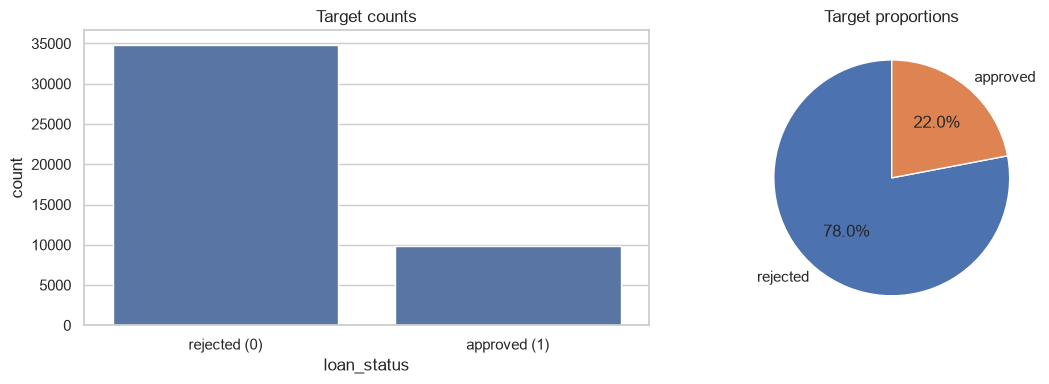


Majority class share: 78.0%
A model that always predicts 'reject' would score 78.0% accuracy
-- while approving nobody, and therefore being useless.


In [145]:
counts = df_clean[TARGET].value_counts().sort_index()
props = df_clean[TARGET].value_counts(normalize=True).sort_index()

summary = pd.DataFrame({"count": counts, "proportion": props.round(4)})
summary.index = ["0 (rejected)", "1 (approved)"]
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=TARGET, data=df_clean, ax=axes[0])
axes[0].set_title("Target counts")
axes[0].set_xticklabels(["rejected (0)", "approved (1)"])

axes[1].pie(counts, labels=["rejected", "approved"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Target proportions")

plt.tight_layout()
plt.show()

majority = max(props)
print(f"\nMajority class share: {majority:.1%}")
print(f"A model that always predicts 'reject' would score {majority:.1%} accuracy")
print("-- while approving nobody, and therefore being useless.")

**Roughly 22% approved, 78% rejected.**

This is a moderate imbalance — not extreme, but enough to matter. Two consequences:

1. **Accuracy is out** as a primary metric, for the reason printed above.
2. **The models need to be told about it.** Left alone, a classifier minimising overall error will lean toward predicting the majority class. Both `class_weight="balanced"` (scikit-learn) and `scale_pos_weight` (XGBoost) correct for this by weighting minority-class errors more heavily. Section 5 shows the effect concretely.

### 4.2 Numeric feature distributions

Histograms for every numeric column. What we're looking for: skew, unusual shapes, and values clustering in ways that suggest the data was generated rather than observed.

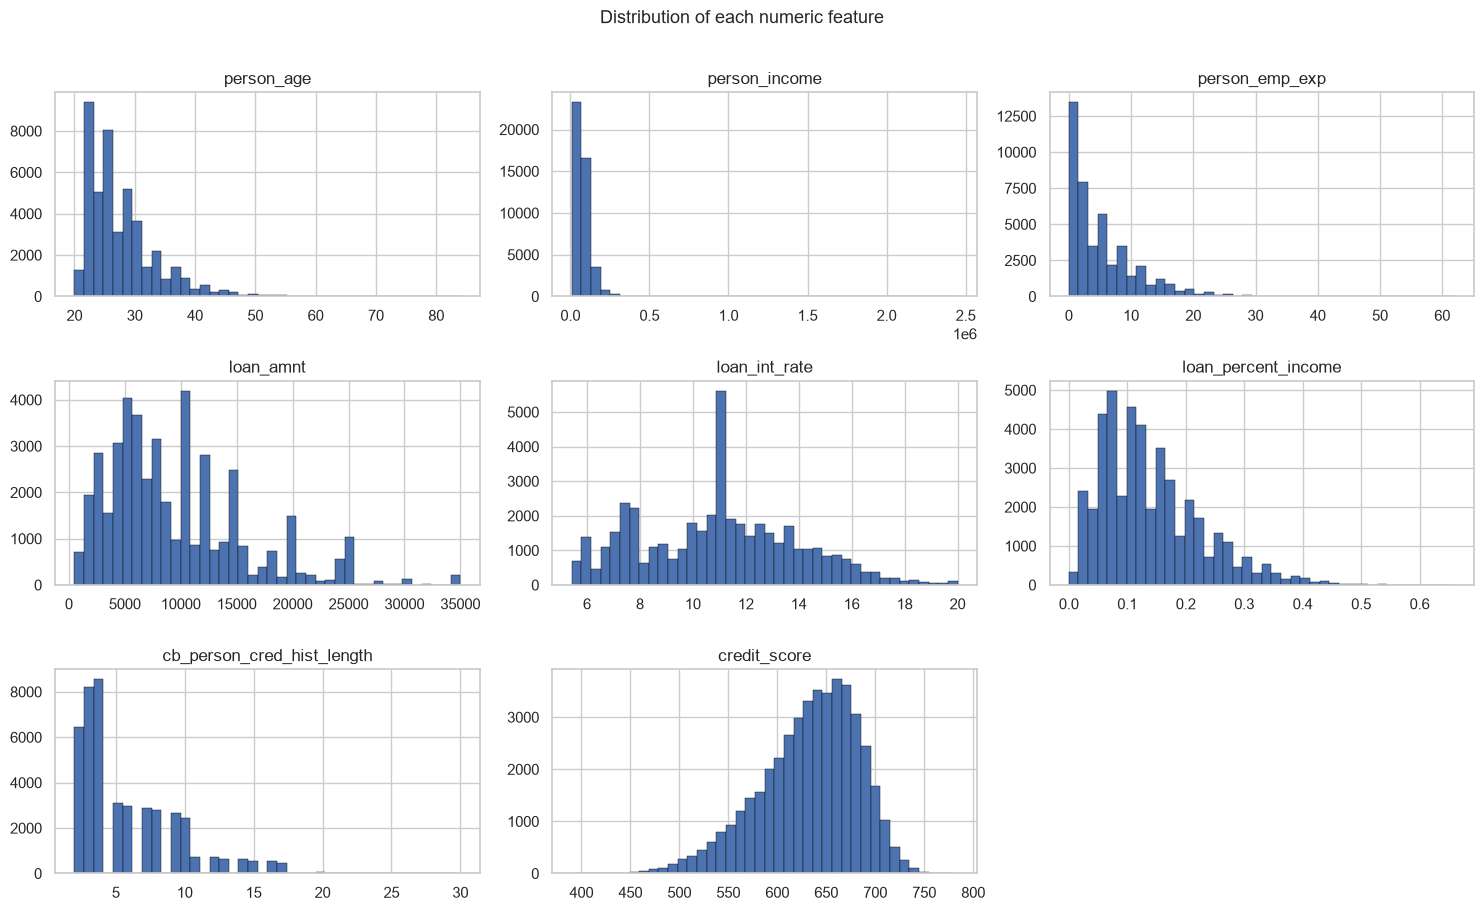

In [146]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
numeric_features = [c for c in numeric_cols if c != TARGET]

df_clean[numeric_features].hist(figsize=(15, 9), bins=40, edgecolor="black", linewidth=0.3)
plt.suptitle("Distribution of each numeric feature", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Reading these:

- **`person_age`** — concentrated in the 20s and low 30s, with a long thin tail. A young applicant pool.
- **`person_income`** — heavily right-skewed, as the summary table predicted.
- **`person_emp_exp`** — right-skewed, most applicants with few years of experience. Consistent with the age distribution.
- **`loan_amnt`** — clustered at round numbers, which is expected: people request 5,000 or 10,000, not 7,431.
- **`loan_int_rate`** — roughly bell-shaped between 5% and 20%.
- **`loan_percent_income`** — right-skewed, most loans small relative to income.
- **`cb_person_cred_hist_length`** — short histories dominate, again consistent with a young applicant pool.
- **`credit_score`** — unimodal and centred around 630, with a mild **left** skew (skew ≈ −0.6): the mean of 633 sits just below the median of 640, and there is a thin tail of low scores reaching down to 390. Not quite normal, but close enough that no transformation is warranted.

### 4.3 Outliers

Boxplots make the spread and the outlying tails easier to see than histograms do.

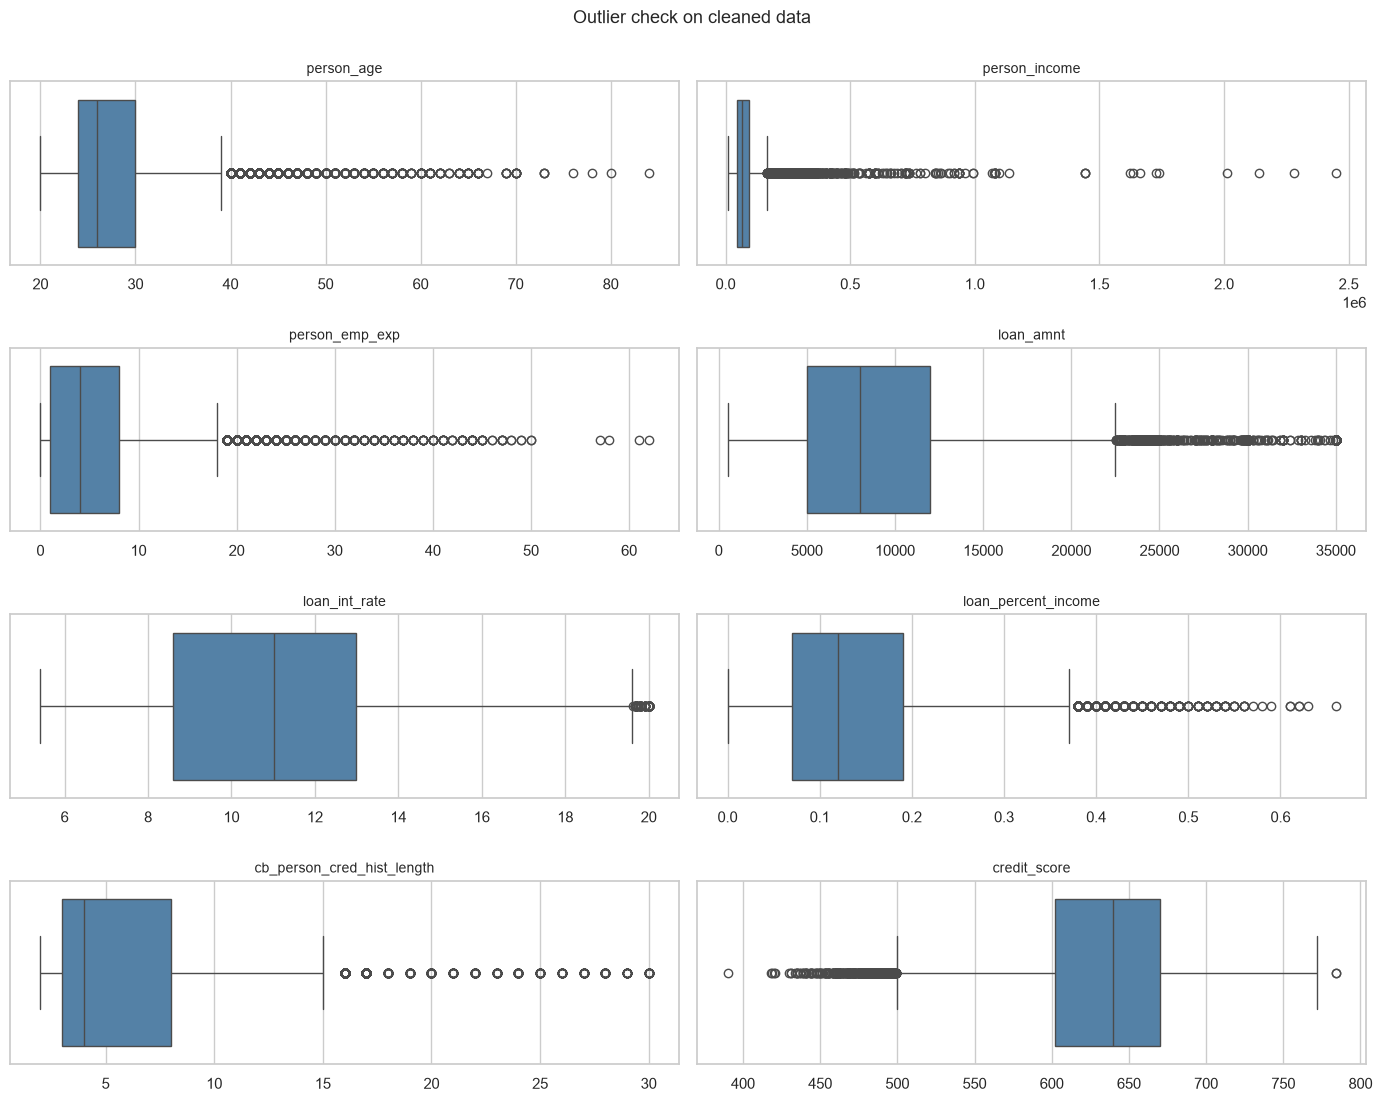

In [147]:
fig, axes = plt.subplots(4, 2, figsize=(14, 11))

for ax, col in zip(axes.ravel(), numeric_features):
    sns.boxplot(x=df_clean[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

plt.suptitle("Outlier check on cleaned data", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

`person_income`, `person_emp_exp` and `cb_person_cred_hist_length` still show long right tails. These are genuine high values, not corruption — a 30-year credit history is unusual but possible, unlike a 144-year-old applicant.

We are not removing them. The final model is tree-based, and trees are unaffected by the magnitude of outliers; they only care about which side of a split a value falls on. Removing legitimate high earners would throw away real information.

### 4.4 Correlations between numeric features

Two things to look for here: which features relate to the target, and which features are redundant with each other.

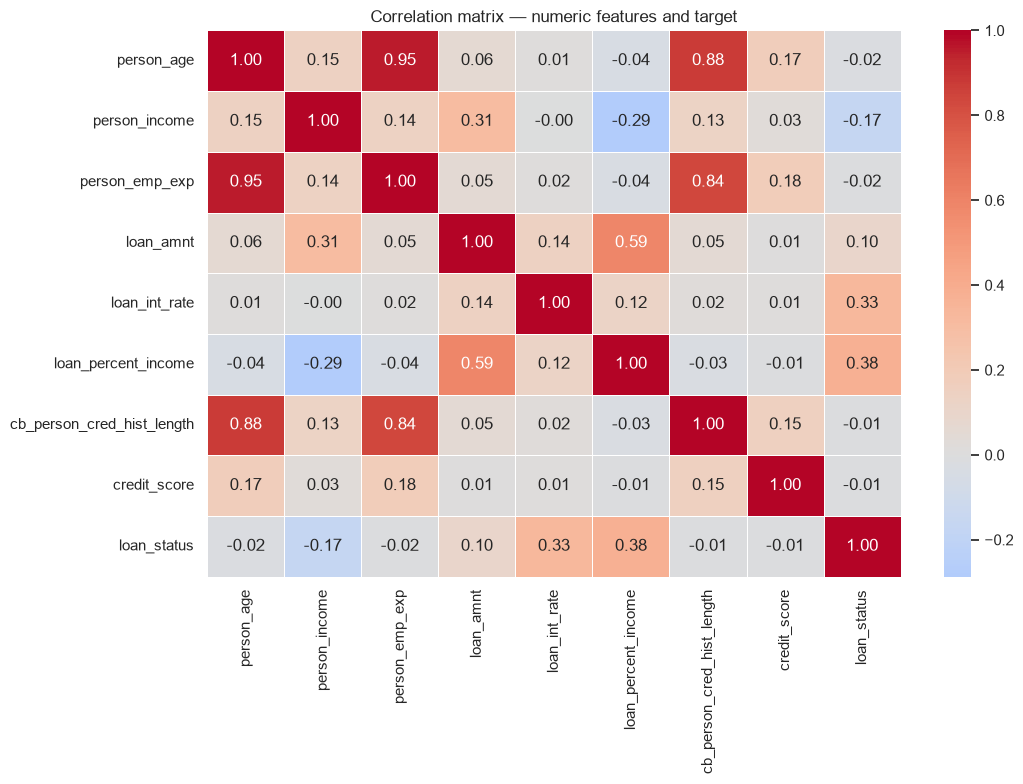

In [148]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=False)
plt.title("Correlation matrix — numeric features and target")
plt.tight_layout()
plt.show()

In [149]:
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation with the target, strongest to weakest:\n")
for feat, val in target_corr.items():
    bar = "#" * int(abs(val) * 60)
    print(f"  {feat:<28} {val:+.3f}  {bar}")

Correlation with the target, strongest to weakest:

  loan_percent_income          +0.378  ######################
  loan_int_rate                +0.332  ###################
  loan_amnt                    +0.099  #####
  credit_score                 -0.007  
  cb_person_cred_hist_length   -0.011  
  person_emp_exp               -0.016  
  person_age                   -0.017  
  person_income                -0.168  ##########


### 4.5 What the correlations say

**Three features show a meaningful relationship with the target:**

- `loan_percent_income` at **+0.38** — the strongest numeric correlate
- `loan_int_rate` at **+0.33**
- `person_income` at **−0.17**

**`loan_amnt` is weak but not absent** at +0.10 — worth carrying into the model, not worth reading anything into on its own.

**Four are effectively zero:** `credit_score`, `cb_person_cred_hist_length`, `person_emp_exp` and `person_age`, all under 0.02 in absolute terms.

Now, the sign of each of those first three deserves attention, because all three point the opposite way to how lending works.

`loan_percent_income` is the loan amount divided by annual income — a debt-to-income ratio. A **higher** ratio means the applicant is asking for more relative to what they earn, which is a core risk factor in underwriting. It should make approval *less* likely. Here it is the single strongest predictor of approval being *more* likely.

`loan_int_rate` is positively correlated with approval. This one is worth stating carefully. The rate is a legitimate part of an application — it is quoted up front and affordability is assessed against it, so a high rate can make a marginal applicant unaffordable and *reduce* their chance of approval. That is the direction real lending would produce. Here the relationship runs the other way.

`person_income` is negatively correlated with approval. Lenders prefer applicants who earn more, not less.

And separately: **`credit_score` correlates with approval at −0.007**, which is to say, not at all. Credit score is the single feature in a credit dataset most designed to predict whether someone should be lent to. A dataset where it has no relationship with the lending decision is strange.

None of these is individually conclusive, but together they say something important about the data: **this dataset's internal decision logic is not real lending logic.** It is synthetic, and whatever process generated it does not reproduce how a bank actually underwrites.

That is worth being clear about now rather than discovering later. It does not stop us modelling — the relationships are genuinely present, and a model that learns them is doing its job correctly. What it does mean is that performance figures from this notebook describe *this dataset*, not how the same approach would perform on real applications. Section 13 records it under limitations.

**One more thing the heatmap shows:** `person_age`, `person_emp_exp` and `cb_person_cred_hist_length` are strongly correlated *with each other*. Let's quantify that, because redundant features affect model choice.

In [150]:
age_like = ["person_age", "person_emp_exp", "cb_person_cred_hist_length"]

print("Correlations among the age-related features:\n")
print(df_clean[age_like].corr().round(3).to_string())

Correlations among the age-related features:

                            person_age  person_emp_exp  cb_person_cred_hist_length
person_age                       1.000           0.952                       0.879
person_emp_exp                   0.952           1.000                       0.840
cb_person_cred_hist_length       0.879           0.840                       1.000


Correlations of 0.95, 0.88 and 0.84. These three features are largely measuring the same underlying thing — how long the applicant has been an adult with a financial life.

This is **multicollinearity**. For a linear model it is a real problem: the coefficients become unstable and individually uninterpretable, because the model cannot tell which of three near-identical features deserves the credit. For tree-based models it is mostly harmless — the trees will simply pick whichever one splits best and largely ignore the others.

Since the final model will be tree-based, we keep all three. Worth knowing about, not worth acting on here.

### 4.6 Categorical features

Five text columns. First, what values do they take and how common is each?

In [151]:
categorical_features = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()

for col in categorical_features:
    vc = df_clean[col].value_counts()
    pct = df_clean[col].value_counts(normalize=True)
    print(f"--- {col} ({df_clean[col].nunique()} categories) ---")
    print(pd.DataFrame({"count": vc, "share": pct.round(3)}).to_string())
    print()

--- person_gender (2 categories) ---
               count  share
person_gender              
male           24672  0.552
female         20041  0.448

--- person_education (5 categories) ---
                  count  share
person_education              
Bachelor          13302  0.297
Associate         11959  0.267
High School       11886  0.266
Master             6946  0.155
Doctorate           620  0.014

--- person_home_ownership (4 categories) ---
                       count  share
person_home_ownership              
RENT                   23282  0.521
MORTGAGE               18416  0.412
OWN                     2899  0.065
OTHER                    116  0.003

--- loan_intent (6 categories) ---
                   count  share
loan_intent                    
EDUCATION           9084  0.203
MEDICAL             8502  0.190
VENTURE             7763  0.174
PERSONAL            7509  0.168
DEBTCONSOLIDATION   7102  0.159
HOMEIMPROVEMENT     4753  0.106

--- previous_loan_defaults_on_file (2 

No category is so rare that it risks being absent from a train/test split, which means one-hot encoding is safe and no category grouping is needed.

### 4.7 Approval rate by category

Counts tell us the composition of the applicant pool. What we actually want to know is whether each category is associated with a different approval rate.

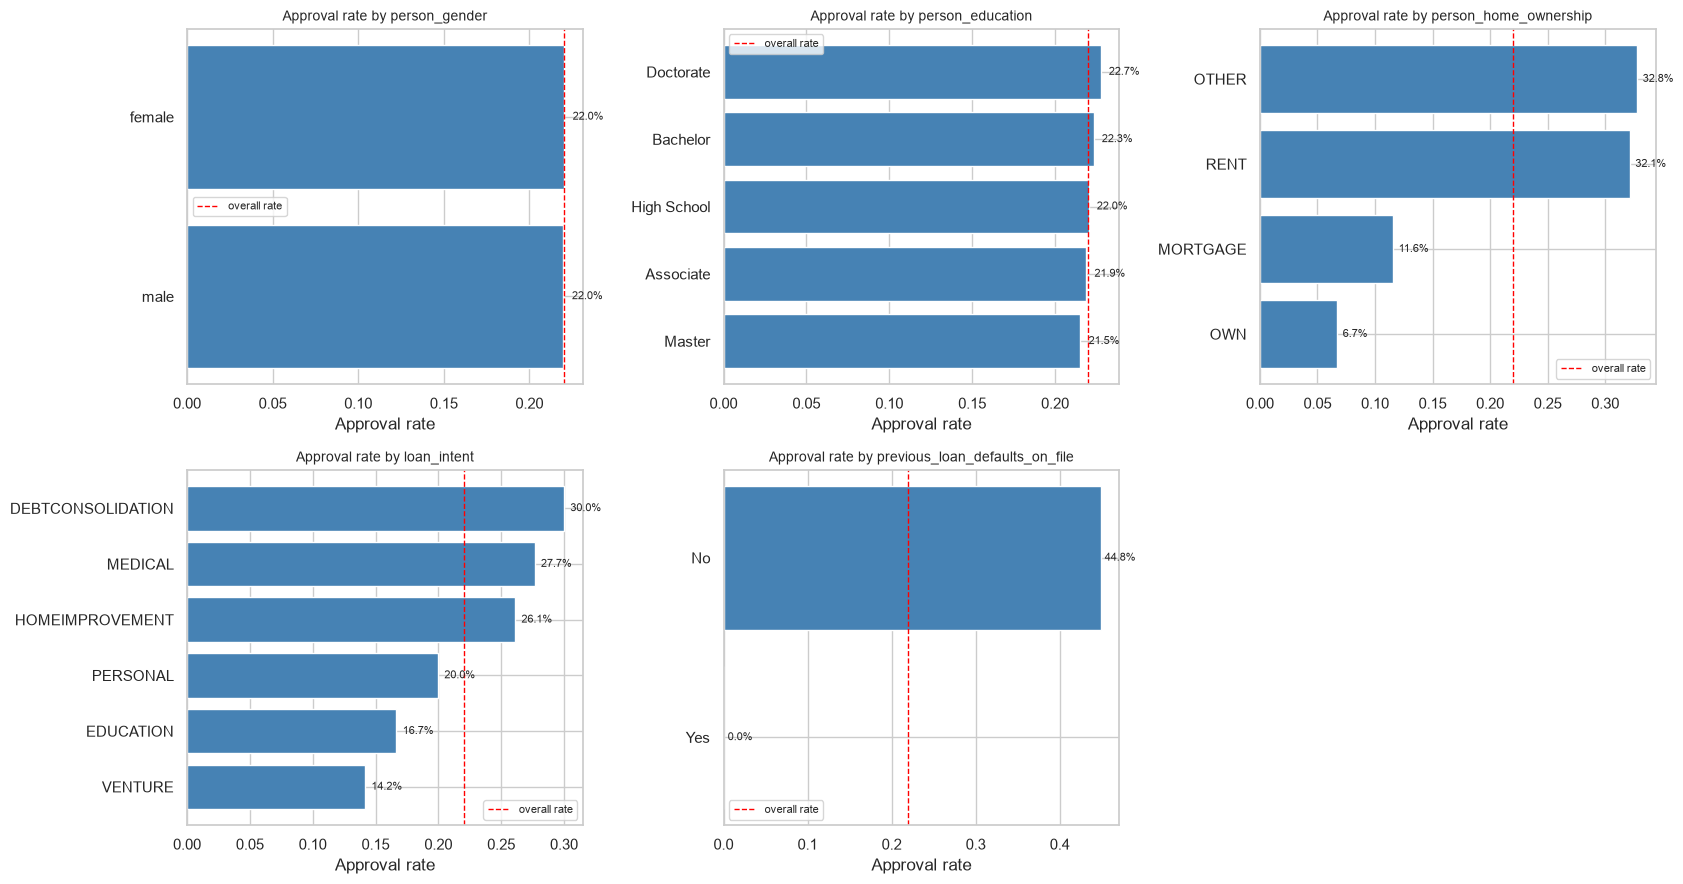

In [152]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, col in zip(axes.ravel(), categorical_features):
    rates = df_clean.groupby(col)[TARGET].agg(["mean", "size"]).sort_values("mean")
    bars = ax.barh(rates.index.astype(str), rates["mean"], color="steelblue")
    ax.axvline(df_clean[TARGET].mean(), color="red", linestyle="--",
               linewidth=1, label="overall rate")
    ax.set_title(f"Approval rate by {col}", fontsize=10)
    ax.set_xlabel("Approval rate")
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{row['mean']:.1%}", va="center", fontsize=8)

for ax in axes.ravel()[len(categorical_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [153]:
# The same information as a table, sorted by how much each category deviates
# from the overall approval rate.
overall = df_clean[TARGET].mean()

rows = []
for col in categorical_features:
    for cat, grp in df_clean.groupby(col):
        rows.append({
            "feature": col,
            "category": cat,
            "n": len(grp),
            "approval_rate": round(grp[TARGET].mean(), 4),
            "vs_overall": round(grp[TARGET].mean() - overall, 4),
        })

cat_table = pd.DataFrame(rows).sort_values("approval_rate")
print(f"Overall approval rate: {overall:.4f}\n")
print(cat_table.to_string(index=False))

Overall approval rate: 0.2200

                       feature          category     n  approval_rate  vs_overall
previous_loan_defaults_on_file               Yes 22776         0.0000     -0.2200
         person_home_ownership               OWN  2899         0.0669     -0.1531
         person_home_ownership          MORTGAGE 18416         0.1156     -0.1045
                   loan_intent           VENTURE  7763         0.1417     -0.0783
                   loan_intent         EDUCATION  9084         0.1667     -0.0534
                   loan_intent          PERSONAL  7509         0.1998     -0.0203
              person_education            Master  6946         0.2152     -0.0048
              person_education         Associate 11959         0.2187     -0.0013
                 person_gender              male 24672         0.2198     -0.0002
              person_education       High School 11886         0.2202      0.0001
                 person_gender            female 20041         0.22

### 4.8 What the categorical features say

**`person_gender` and `person_education` barely move the approval rate.** Every category sits within a couple of percentage points of the overall 22%. On this evidence neither carries much signal.

**`person_home_ownership` matters.** There is a real spread between categories — renting, owning outright and holding a mortgage are associated with visibly different approval rates.

**`loan_intent` matters.** Debt consolidation, medical and home-improvement loans have noticeably different approval rates from venture and education loans.

**`previous_loan_defaults_on_file` is different in kind from all the others.**

Look at the "Yes" row in the table. The approval rate is not merely low — it reads as **exactly 0.0000**. Not 2%, not 0.5%. Zero.

Every other feature in this dataset shifts the odds. This one appears to eliminate them. That is a qualitative difference, and it needs verifying precisely rather than eyeballed off a chart, because a feature that *always* produces one outcome is a fundamentally different thing from a feature that merely makes one outcome likely. Section 7 does that check.

### 4.9 Numeric features against the target

Correlation coefficients only capture linear relationships. A feature could have a strong non-linear relationship and still show a correlation near zero. Binning each numeric feature and plotting the approval rate per bin catches that.

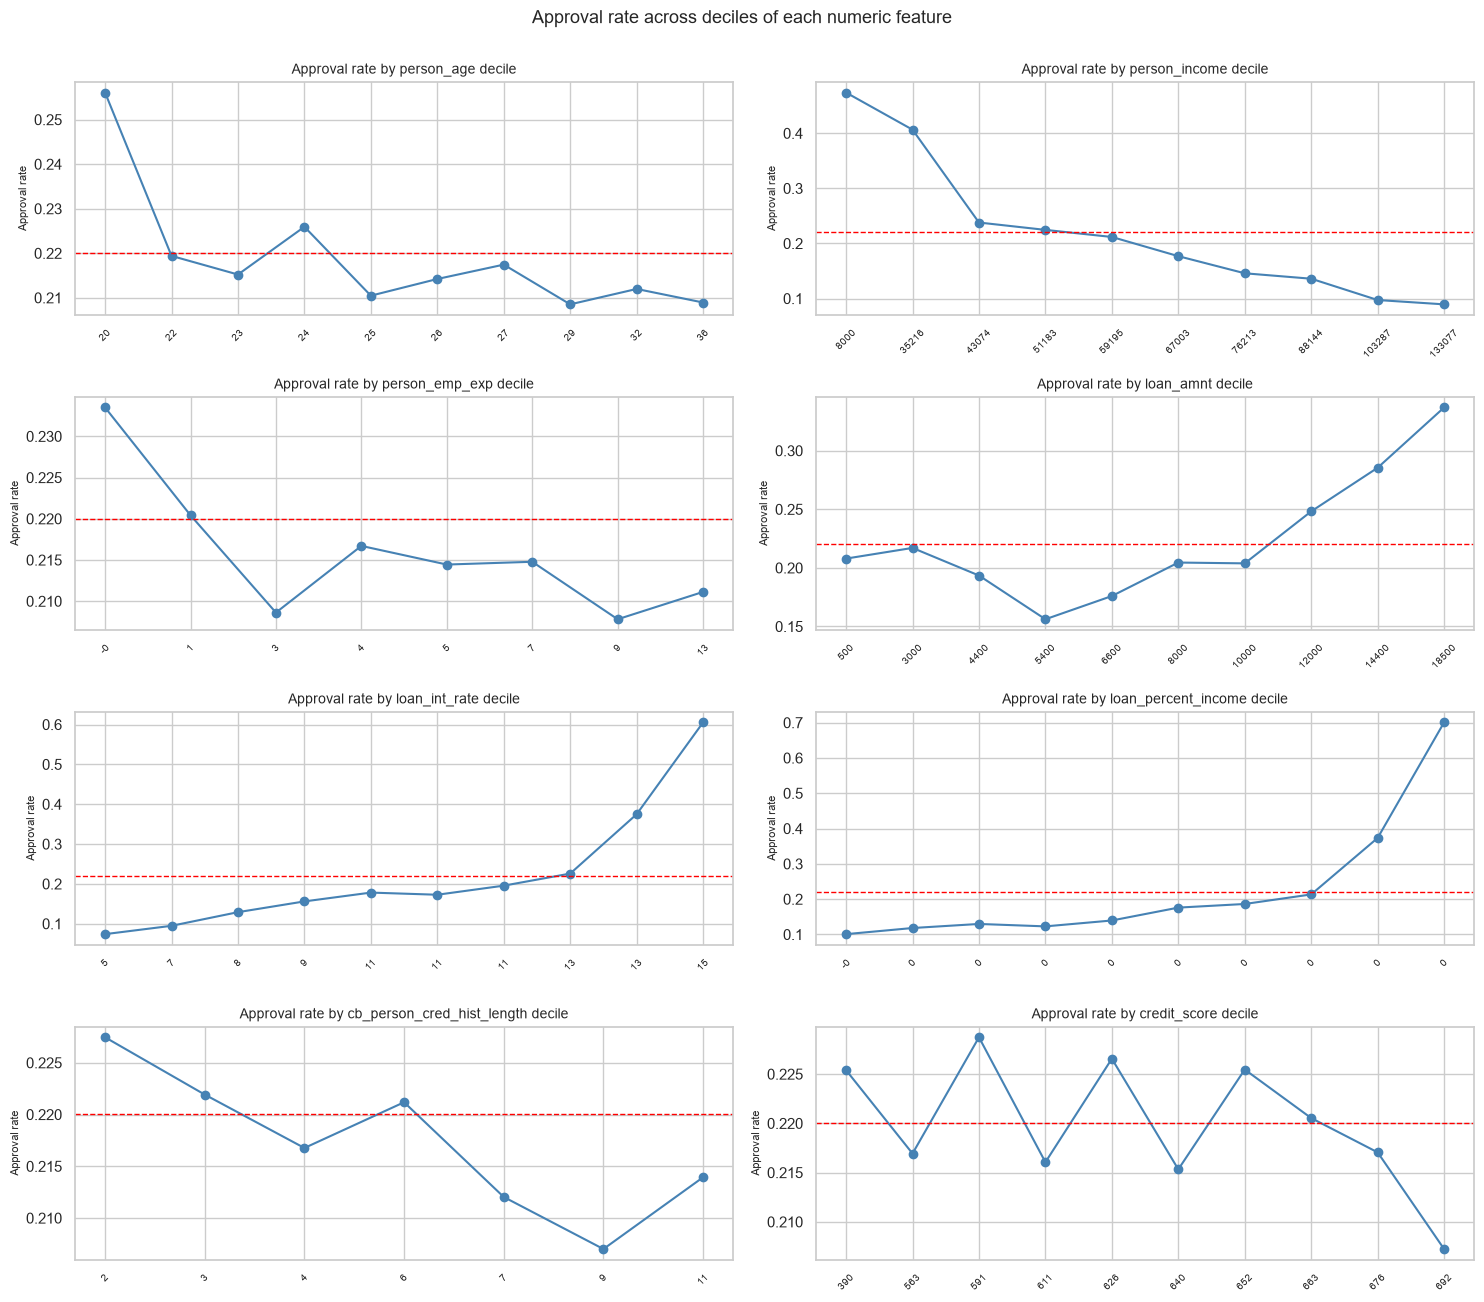

In [154]:
fig, axes = plt.subplots(4, 2, figsize=(15, 13))

for ax, col in zip(axes.ravel(), numeric_features):
    try:
        bins = pd.qcut(df_clean[col], 10, duplicates="drop")
    except ValueError:
        bins = pd.cut(df_clean[col], 10)

    rates = df_clean.groupby(bins, observed=True)[TARGET].mean()

    ax.plot(range(len(rates)), rates.values, marker="o", color="steelblue")
    ax.axhline(overall, color="red", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels([f"{iv.left:.0f}" for iv in rates.index], rotation=45, fontsize=7)
    ax.set_title(f"Approval rate by {col} decile", fontsize=10)
    ax.set_ylabel("Approval rate", fontsize=8)

plt.suptitle("Approval rate across deciles of each numeric feature", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

These confirm and extend the correlation table.

`loan_percent_income` shows a clear, steadily rising relationship — the strongest and most orderly pattern of any numeric feature. `loan_int_rate` rises similarly. `person_income` declines. All three are monotonic, so the correlation coefficient was capturing them fairly.

`credit_score` is flat. Not noisy — flat. The approval rate barely moves from the lowest decile to the highest. Whatever is driving decisions in this dataset, credit score is not visibly part of it.

`person_age`, `person_emp_exp`, `cb_person_cred_hist_length` and `loan_amnt` are all close to flat as well.

### 4.10 EDA summary

**Data quality:** 44,713 usable rows after removing six corrupted records. No missing values, no duplicates.

**Target:** 22% approved, 78% rejected. Moderate imbalance — accuracy unusable as a metric, class weighting needed during training.

**Strongest signals:** `loan_percent_income`, `loan_int_rate`, `person_income`, `person_home_ownership`, `loan_intent`.

**Weak or absent signals:** `person_gender`, `person_education`, `credit_score`, `person_age`, `person_emp_exp`, `cb_person_cred_hist_length`, `loan_amnt`.

**Structural notes:** the three age-related features are heavily collinear; income and loan amount are right-skewed.

**An oddity worth recording.** The direction of the strongest correlations runs counter to real lending logic: higher debt-to-income, higher interest rates and lower income all associate with *higher* approval, and credit score appears irrelevant. This dataset is synthetic, and its internal decision process is not a faithful simulation of a bank's. The model will learn these relationships because they are genuinely present in the data — that is correct behaviour, not a bug — but it means performance figures here describe this dataset rather than real underwriting. Section 13 revisits this under limitations.

**One thing requiring investigation before modelling.** `previous_loan_defaults_on_file == "Yes"` appears to produce a 0% approval rate. If that is exact rather than merely low, it is a rule rather than a statistical relationship — and rules and signals call for completely different treatment. Section 7 checks it.

---

## 5. A first model, using every feature

Before making any decisions about which features to keep, it is worth building a model on all of them. This gives a reference point, and — more importantly — lets us ask the model itself which features it relies on.

The order matters here. Dropping features based on intuition risks discarding something useful; dropping them based on what the model actually does is defensible. So: fit first, inspect second, decide third.

### 5.1 Train / validation / test split

Three splits, not two:

- **Train (70%)** — fits model parameters.
- **Validation (15%)** — compares models and selects the decision threshold.
- **Test (15%)** — reports final performance, and is used for nothing else.

The validation set exists because of the threshold. The threshold is a parameter we choose, and choosing it by looking at test performance would make the reported test numbers optimistic. Keeping a third split means the final figures stay honest.

All splits are **stratified** on the target, so the 22% approval rate is preserved in each one. Without stratification a random split could easily produce a test set with a noticeably different class balance, making the metrics incomparable.

In [155]:
X_all = df_clean.drop(columns=[TARGET])
y_all = df_clean[TARGET]

# First split: hold back 30% for validation + test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)

# Second split: halve that 30% into validation and test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

split_summary = pd.DataFrame([
    {"split": "train",      "rows": len(X_train), "approval_rate": round(y_train.mean(), 4)},
    {"split": "validation", "rows": len(X_val),   "approval_rate": round(y_val.mean(), 4)},
    {"split": "test",       "rows": len(X_test),  "approval_rate": round(y_test.mean(), 4)},
])
print(split_summary.to_string(index=False))
print(f"\nTotal: {len(X_train) + len(X_val) + len(X_test):,} rows")
print("Approval rates agree to within 0.0002 -- stratification worked.")

     split  rows  approval_rate
     train 31299         0.2200
validation  6707         0.2201
      test  6707         0.2199

Total: 44,713 rows
Approval rates agree to within 0.0002 -- stratification worked.


### 5.2 Preprocessing

Two transformations are needed before a model can consume this data.

**Categorical columns must be encoded.** A model cannot multiply `"RENT"` by a coefficient. One-hot encoding turns each category into its own 0/1 column. We use `drop="first"`, which omits one category per feature — this avoids perfect multicollinearity among the dummy columns, which matters for the logistic regression baseline. `handle_unknown="ignore"` means a category never seen during training won't crash inference.

**Numeric columns are scaled.** Logistic regression is sensitive to feature magnitude: without scaling, `person_income` (tens of thousands) would dominate `loan_percent_income` (0 to 1) purely because of units. `StandardScaler` centres each feature at zero with unit variance. Tree models don't need this, but it costs nothing and lets every model in this section share one preprocessor.

In [156]:
cat_cols_all = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols_all = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical ({len(cat_cols_all)}): {cat_cols_all}")
print(f"Numeric     ({len(num_cols_all)}): {num_cols_all}")

preprocessor_all = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_all),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_all),
])

# Fit on training data only, to see the resulting width.
_ = preprocessor_all.fit(X_train)
print(f"\nAfter encoding: {len(num_cols_all)} numeric + "
      f"{len(preprocessor_all.get_feature_names_out()) - len(num_cols_all)} "
      f"one-hot columns = {len(preprocessor_all.get_feature_names_out())} total")

Categorical (5): ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numeric     (8): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

After encoding: 8 numeric + 14 one-hot columns = 22 total


### 5.3 Baseline: logistic regression

Starting simple establishes a floor. If a heavily tuned gradient-boosting model barely beats logistic regression, the extra complexity isn't earning its place.

Fitting it twice — once naively, once with class weighting — makes the effect of the imbalance visible rather than theoretical.

In [157]:
logreg_plain = Pipeline([
    ("prep", preprocessor_all),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg_plain.fit(X_train, y_train)

pred = logreg_plain.predict(X_val)
proba = logreg_plain.predict_proba(X_val)[:, 1]

print("LOGISTIC REGRESSION -- no class weighting")
print(f"ROC-AUC: {roc_auc_score(y_val, proba):.4f}")
print(f"\nConfusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y_val, pred))
print(f"\n{classification_report(y_val, pred, target_names=['rejected', 'approved'])}")

LOGISTIC REGRESSION -- no class weighting
ROC-AUC: 0.9549

Confusion matrix (rows = actual, cols = predicted):
[[4930  301]
 [ 377 1099]]

              precision    recall  f1-score   support

    rejected       0.93      0.94      0.94      5231
    approved       0.79      0.74      0.76      1476

    accuracy                           0.90      6707
   macro avg       0.86      0.84      0.85      6707
weighted avg       0.90      0.90      0.90      6707



In [158]:
logreg = Pipeline([
    ("prep", preprocessor_all),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

pred_lr = logreg.predict(X_val)
proba_lr = logreg.predict_proba(X_val)[:, 1]

print("LOGISTIC REGRESSION -- class_weight='balanced'")
print(f"ROC-AUC: {roc_auc_score(y_val, proba_lr):.4f}")
print(f"\nConfusion matrix:")
print(confusion_matrix(y_val, pred_lr))
print(f"\n{classification_report(y_val, pred_lr, target_names=['rejected', 'approved'])}")

LOGISTIC REGRESSION -- class_weight='balanced'
ROC-AUC: 0.9550

Confusion matrix:
[[4410  821]
 [ 119 1357]]

              precision    recall  f1-score   support

    rejected       0.97      0.84      0.90      5231
    approved       0.62      0.92      0.74      1476

    accuracy                           0.86      6707
   macro avg       0.80      0.88      0.82      6707
weighted avg       0.90      0.86      0.87      6707



### 5.4 What class weighting did

Compare the two outputs above and notice which numbers moved.

**ROC-AUC barely changed.** **Recall on the approved class jumped substantially, and precision fell.**

That pattern is worth understanding properly, because it explains why we tune a threshold later.

**ROC-AUC measures ranking.** It asks: if you pick a random approved applicant and a random rejected one, how often does the model score the approved one higher? Class weighting doesn't teach the model anything new about who is more creditworthy, so the ranking — and therefore the AUC — stays roughly the same.

**Precision and recall measure where you cut.** `predict()` approves everything scoring above 0.5. Class weighting shifts the scores upward for the minority class, which pushes more applicants over that fixed 0.5 line. More approvals means catching more of the genuinely approvable ones (recall up) but also more mistakes (precision down).

So class weighting is really just an indirect way of moving the cutoff. Section 11 moves it directly and deliberately instead, which gives far better control.

### 5.5 Random Forest

In [159]:
rf = Pipeline([
    ("prep", preprocessor_all),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)
proba_rf = rf.predict_proba(X_val)[:, 1]

print("RANDOM FOREST")
print(f"ROC-AUC: {roc_auc_score(y_val, proba_rf):.4f}")
print(f"\nConfusion matrix:")
print(confusion_matrix(y_val, pred_rf))
print(f"\n{classification_report(y_val, pred_rf, target_names=['rejected', 'approved'])}")

RANDOM FOREST
ROC-AUC: 0.9750

Confusion matrix:
[[4925  306]
 [ 223 1253]]

              precision    recall  f1-score   support

    rejected       0.96      0.94      0.95      5231
    approved       0.80      0.85      0.83      1476

    accuracy                           0.92      6707
   macro avg       0.88      0.90      0.89      6707
weighted avg       0.92      0.92      0.92      6707



A clear improvement on logistic regression, which tells us the relationships in this data are non-linear — exactly what tree ensembles are built for.

### 5.6 XGBoost

Gradient boosting is the expected best performer on tabular data of this size and shape.

The hyperparameters are deliberately conservative:

- **`max_depth=4`** — shallow trees. Deep trees memorise training rows; with ~31,000 rows, depth 4 captures interactions without overfitting.
- **`n_estimators=300`** with **`learning_rate=0.05`** — many small steps rather than few large ones. Slower to train, generalises better.
- **`subsample=0.8`** and **`colsample_bytree=0.8`** — each tree sees 80% of rows and 80% of features, which decorrelates the trees and acts as regularisation.
- **`scale_pos_weight`** — XGBoost's equivalent of `class_weight="balanced"`, set to the ratio of negative to positive examples.

In [160]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Negative examples: {(y_train == 0).sum():,}")
print(f"Positive examples: {(y_train == 1).sum():,}")
print(f"scale_pos_weight = {scale_pos_weight:.3f}")
print(f"  -> each approved applicant counts {scale_pos_weight:.2f}x as much during training\n")

xgb = Pipeline([
    ("prep", preprocessor_all),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )),
])
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_val)
proba_xgb = xgb.predict_proba(X_val)[:, 1]

print("XGBOOST")
print(f"ROC-AUC: {roc_auc_score(y_val, proba_xgb):.4f}")
print(f"\nConfusion matrix:")
print(confusion_matrix(y_val, pred_xgb))
print(f"\n{classification_report(y_val, pred_xgb, target_names=['rejected', 'approved'])}")

Negative examples: 24,412
Positive examples: 6,887
scale_pos_weight = 3.545
  -> each approved applicant counts 3.54x as much during training

XGBOOST
ROC-AUC: 0.9761

Confusion matrix:
[[4672  559]
 [ 111 1365]]

              precision    recall  f1-score   support

    rejected       0.98      0.89      0.93      5231
    approved       0.71      0.92      0.80      1476

    accuracy                           0.90      6707
   macro avg       0.84      0.91      0.87      6707
weighted avg       0.92      0.90      0.90      6707



### 5.7 Is that score real, or a lucky split?

A single validation score could be an artifact of which rows happened to land where. Five-fold cross-validation on the training set refits the model five times on different partitions and reports the spread.

In [161]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("Cross-validated ROC-AUC on the training set:\n")
for k, s in enumerate(cv_scores, 1):
    print(f"  fold {k}: {s:.4f}")
print(f"\n  mean: {cv_scores.mean():.4f}")
print(f"  std:  {cv_scores.std():.4f}")
print(f"  range: {cv_scores.min():.4f} to {cv_scores.max():.4f}")

Cross-validated ROC-AUC on the training set:

  fold 1: 0.9750
  fold 2: 0.9721
  fold 3: 0.9766
  fold 4: 0.9765
  fold 5: 0.9725

  mean: 0.9745
  std:  0.0019
  range: 0.9721 to 0.9766


A small standard deviation means the performance is a property of the data, not of one convenient split. Had the folds disagreed substantially, nothing built on top of this would be trustworthy.

### 5.8 Model comparison

In [162]:
def evaluate(name, y_true, y_proba, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
        "precision": round(precision_score(y_true, y_pred), 3),
        "recall": round(recall_score(y_true, y_pred), 3),
        "F1": round(f1_score(y_true, y_pred), 3),
        "FP (bad approvals)": fp,
        "FN (lost customers)": fn,
    }


comparison = pd.DataFrame([
    evaluate("Logistic Regression", y_val, proba_lr, pred_lr),
    evaluate("Random Forest", y_val, proba_rf, pred_rf),
    evaluate("XGBoost", y_val, proba_xgb, pred_xgb),
])
print(comparison.to_string(index=False))

              model  ROC-AUC  precision  recall    F1  FP (bad approvals)  FN (lost customers)
Logistic Regression   0.9550      0.623   0.919 0.743                 821                  119
      Random Forest   0.9750      0.804   0.849 0.826                 306                  223
            XGBoost   0.9761      0.709   0.925 0.803                 559                  111


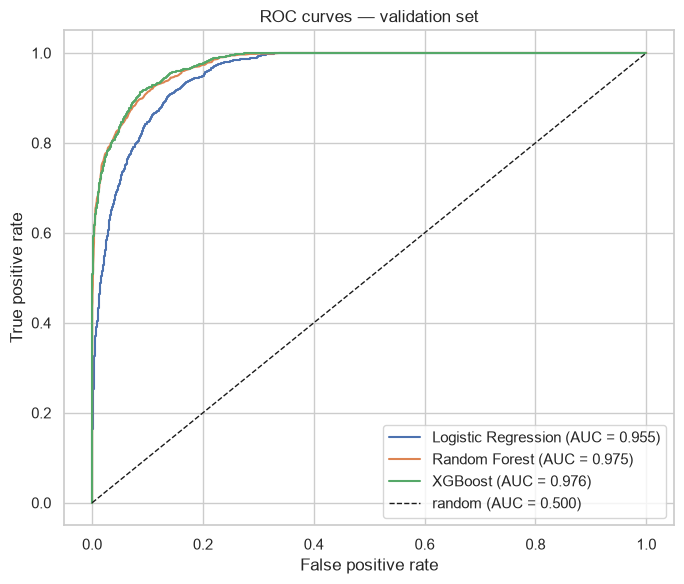

In [163]:
# ROC curves for all three, on the validation set.
plt.figure(figsize=(7, 6))

for name, proba in [("Logistic Regression", proba_lr),
                    ("Random Forest", proba_rf),
                    ("XGBoost", proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_val, proba):.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="random (AUC = 0.500)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — validation set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**XGBoost has the highest ROC-AUC — but only just, and the margin should not be oversold.** It beats Random Forest by 0.0011, while the cross-validation in 5.7 put the standard deviation across folds at 0.0019. The gap between the two models is smaller than the run-to-run variation of either. On ranking quality they are, on this evidence, indistinguishable; only logistic regression is clearly behind.

**The precision and false-positive columns look worse for XGBoost, and that is misleading.** Random Forest shows 306 false positives against XGBoost's 559. Read at face value that matters a great deal, because Section 11.3 argues a bad approval costs roughly ten times a lost customer. But every row in that table is computed at the default 0.5 cutoff, and 0.5 is arbitrary — it is precisely the choice Section 11 exists to replace. Moving the threshold trades false positives against false negatives along each model's own curve, so a comparison at one fixed cutoff says more about where each model's scores happen to pile up than about which model is better. ROC-AUC is the right comparator here because it is the one number that does not depend on that choice.

**XGBoost is carried forward**, on a narrow AUC lead plus two practical grounds: `scale_pos_weight` gives direct control over the class imbalance, and `TreeExplainer` is exact and fast on boosted trees, which the explanation layer in Sections 6 and 12 depends on. Random Forest would have been a defensible choice too, and saying so is more honest than manufacturing a winner out of 0.0011.

But first, a more important question than which algorithm won: **what is this model actually using to make its decisions?**

---

## 6. Explaining the model with SHAP

A good ROC-AUC tells us the model works. It says nothing about *how*, and for a credit model that second question matters at least as much — both for catching problems and because "why was I declined?" is a question a lender is often legally required to answer.

### 6.1 What SHAP does

**SHAP (SHapley Additive exPlanations)** assigns every feature a signed contribution to every individual prediction, measured in log-odds. Three properties make it the right tool here:

1. **Additive.** For any single applicant, the feature contributions sum exactly to the difference between the model's output for them and the model's average output. Nothing is unaccounted for.
2. **Signed.** A positive value pushed this prediction toward approval; a negative value pushed it away. So we can say not just *that* a feature mattered but *which way*.
3. **Exact for trees.** `TreeExplainer` computes the values analytically for tree ensembles rather than approximating them.

Below we compute SHAP values for every applicant in the validation set.

In [164]:
# SHAP needs the bare model and the already-transformed matrix, so we pull
# the two pieces out of the fitted pipeline.
fitted_model = xgb.named_steps["model"]
fitted_prep = xgb.named_steps["prep"]

X_val_transformed = fitted_prep.transform(X_val)
transformed_names = fitted_prep.get_feature_names_out()

X_val_shap = pd.DataFrame(
    X_val_transformed.toarray() if sp.issparse(X_val_transformed) else X_val_transformed,
    columns=transformed_names,
)

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer(X_val_shap)

print(f"SHAP values computed for {X_val_shap.shape[0]:,} applicants "
      f"across {X_val_shap.shape[1]} encoded features.")

SHAP values computed for 6,707 applicants across 22 encoded features.


### 6.2 Global feature importance

The bar chart below ranks features by **mean absolute SHAP value** — the average size of each feature's contribution, regardless of direction. This answers the question of which features the model relies on most.

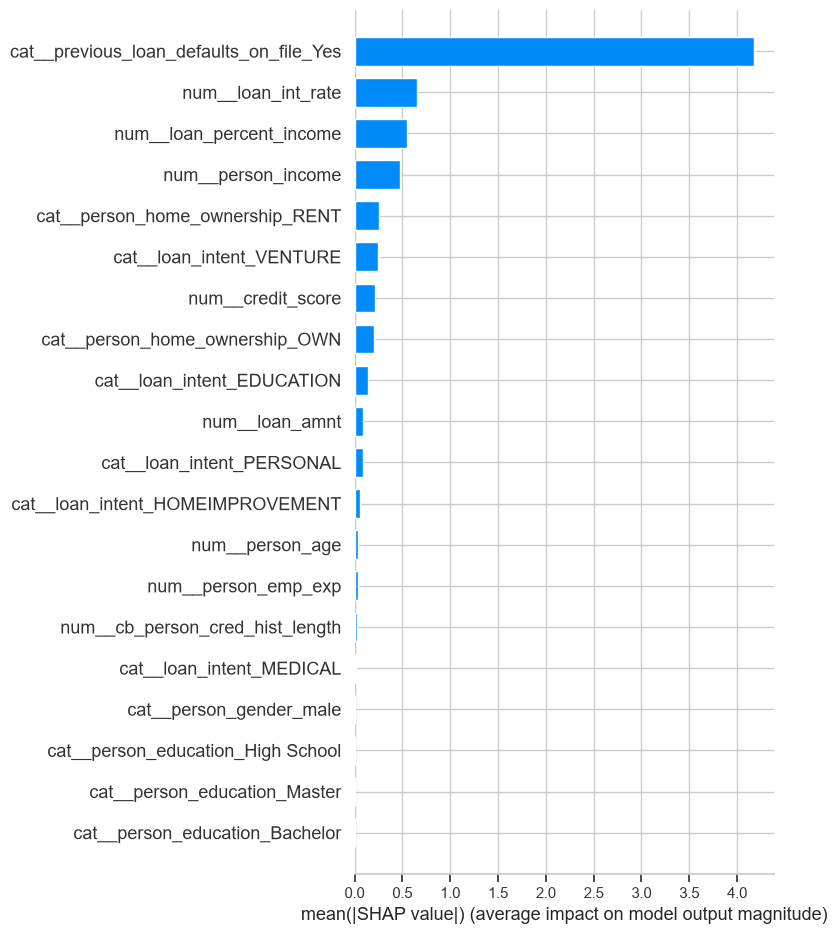

In [165]:
shap.summary_plot(shap_values, X_val_shap, plot_type="bar", show=True)

### 6.3 Direction as well as magnitude

The beeswarm plot below shows every applicant as a point, for every feature. Position on the x-axis is the SHAP contribution; colour is the feature's value (red = high, blue = low).

This is more informative than the bar chart because it shows *direction*: if red points sit on the right, high values of that feature push toward approval.

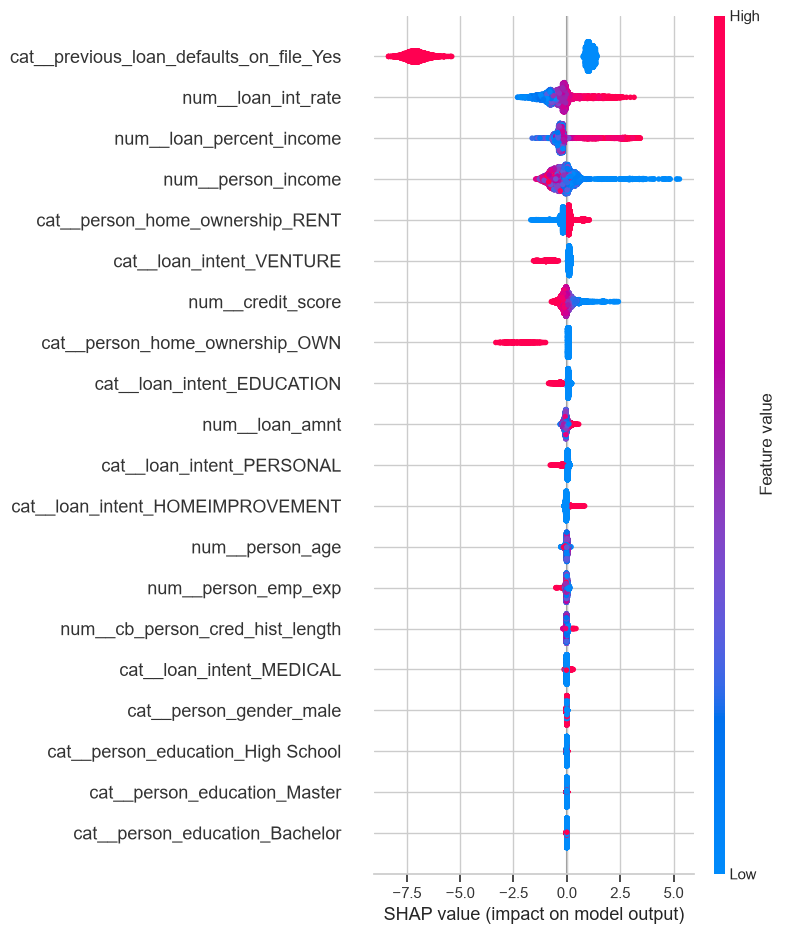

In [166]:
shap.summary_plot(shap_values, X_val_shap, show=True)

### 6.4 A single prediction, decomposed

The waterfall plot takes one applicant and shows how the model arrived at their score, starting from the average prediction and adding each feature's contribution in turn.

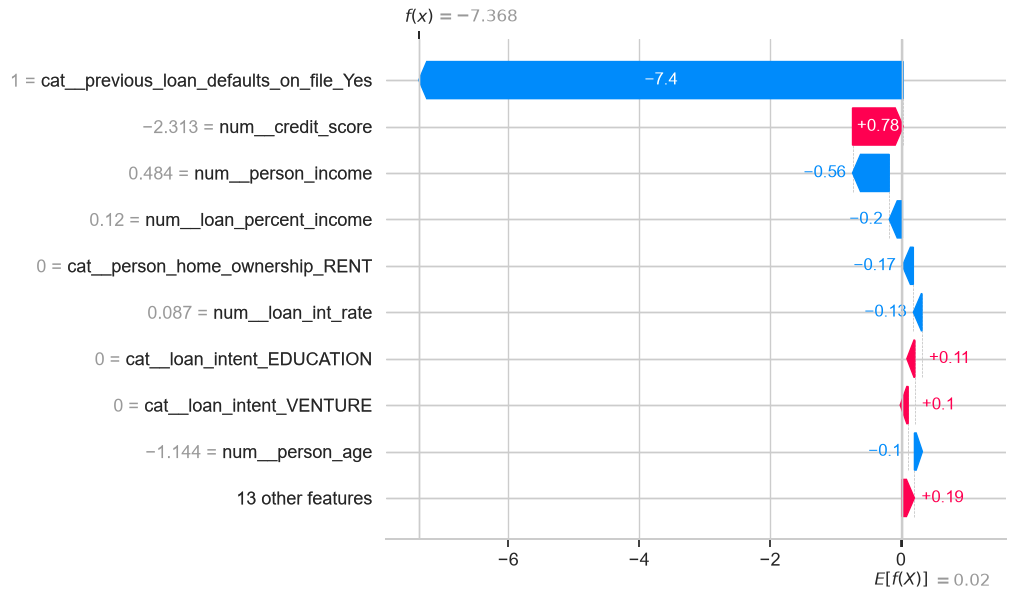

In [167]:
shap.plots.waterfall(shap_values[0])

In [168]:
# The same information as a sorted table, which is easier to quote precisely.
mean_abs = np.abs(shap_values.values).mean(axis=0)

importance = (pd.DataFrame({"encoded_feature": transformed_names,
                            "mean_abs_shap": mean_abs})
              .sort_values("mean_abs_shap", ascending=False)
              .reset_index(drop=True))

importance["share_of_total"] = (importance["mean_abs_shap"] /
                                importance["mean_abs_shap"].sum()).round(4)

print("Feature importance by mean absolute SHAP value:\n")
print(importance.head(20).to_string(index=False))

Feature importance by mean absolute SHAP value:

                        encoded_feature  mean_abs_shap  share_of_total
cat__previous_loan_defaults_on_file_Yes       4.176665          0.5746
                     num__loan_int_rate       0.657401          0.0904
               num__loan_percent_income       0.543273          0.0747
                     num__person_income       0.479143          0.0659
        cat__person_home_ownership_RENT       0.258865          0.0356
               cat__loan_intent_VENTURE       0.249166          0.0343
                      num__credit_score       0.215878          0.0297
         cat__person_home_ownership_OWN       0.199224          0.0274
             cat__loan_intent_EDUCATION       0.137226          0.0189
                         num__loan_amnt       0.083807          0.0115
              cat__loan_intent_PERSONAL       0.083321          0.0115
       cat__loan_intent_HOMEIMPROVEMENT       0.060527          0.0083
                        num_

### 6.5 Reading the results

Four findings, in descending order of how much they change what we do next.

**1. `previous_loan_defaults_on_file` dominates.** It is the largest contributor by a wide margin, accounting for a substantial share of all explanatory weight in the model. Every other feature is competing for what's left. This is consistent with the 0% approval rate seen in Section 4.7, and it makes the check in Section 7 the highest priority.

**2. `person_gender` and `person_education` contribute essentially nothing.** Their mean absolute SHAP values sit at the bottom of the table. The model was given both and effectively declined to use either — which matches the EDA, where neither shifted the approval rate by more than a couple of points.

**3. `loan_int_rate` is among the strongest features**, and the beeswarm shows high rates (red) pushing toward approval.

The rate is a legitimate input to an approval decision. It is quoted or proposed as part of the application, and affordability is assessed *at that rate* — a high rate raises the repayment burden and can turn an otherwise-approvable applicant into an unaffordable one. It is not a value that only materialises after the decision.

The *direction* here is still the opposite of what real lending would produce, for the reason recorded in Section 4.5: this dataset's internal logic does not reproduce real underwriting. The model is learning what the data contains, which is the correct behaviour. The feature stays.

**4. `credit_score` contributes surprisingly little.** Around 3% of total explanatory weight, seventh in the ranking — behind the interest rate, the loan-to-income ratio, income itself, and two categorical dummies. For the feature most designed to summarise creditworthiness, being outranked by whether the applicant rents is odd, and worth returning to.

The next section investigates finding 1, because a feature that dominates a model *and* appears to produce a deterministic outcome needs to be understood before anything else is decided.

---

## 7. Investigating the dominant feature

Section 4.7 showed the approval rate for applicants with a prior default reading as 0.0000. Section 6 showed that same feature dominating the model. Both point to the same question.

### 7.1 A statistical relationship, or a rule?

The distinction is not pedantic — it determines the correct way to handle the feature:

- A **statistical relationship** ("prior defaulters are rarely approved") is something a model should learn, weigh against everything else, and occasionally override when other factors are strong enough.
- A **rule** ("prior defaulters are never approved") is policy. A model cannot improve on it, will only ever approximate it imperfectly, and burns capacity trying.

The test is simply whether any exceptions exist.

In [169]:
prior_default_col = "previous_loan_defaults_on_file"

flagged = df_clean[prior_default_col] == "Yes"

crosstab = pd.crosstab(df_clean[prior_default_col], df_clean[TARGET],
                       margins=True, margins_name="total")
crosstab.columns = ["rejected (0)", "approved (1)", "total"]
print("Prior default status vs outcome:\n")
print(crosstab.to_string())
print()

exceptions = df_clean[flagged & (df_clean[TARGET] == 1)]

print(f"Applicants with a prior default:  {flagged.sum():,} "
      f"({flagged.mean():.1%} of all applicants)")
print(f"Of those, approved:               {len(exceptions):,}")
print(f"Rule holds for:                   {(1 - len(exceptions) / flagged.sum()):.4%} of them")
print()
print(f"Approval rate, prior default = Yes: {df_clean.loc[flagged, TARGET].mean():.6f}")
print(f"Approval rate, prior default = No:  {df_clean.loc[~flagged, TARGET].mean():.6f}")

Prior default status vs outcome:

                                rejected (0)  approved (1)  total
previous_loan_defaults_on_file                                   
No                                     12099          9838  21937
Yes                                    22776             0  22776
total                                  34875          9838  44713

Applicants with a prior default:  22,776 (50.9% of all applicants)
Of those, approved:               0
Rule holds for:                   100.0000% of them

Approval rate, prior default = Yes: 0.000000
Approval rate, prior default = No:  0.448466


**Zero exceptions out of 22,776 applicants.** Not a small fraction — none.

That is a rule. Real outcomes are noisy; no genuine behavioural relationship holds perfectly across twenty-two thousand cases. A perfect 0-for-22,776 is the fingerprint of something written into the data deliberately — the equivalent of `if prior_default: status = 0`.

And notice how much of the dataset that covers: **50.9% of all applicants**. Over half the data has an outcome that was decided by a single field, with no reference to income, credit score, loan size or anything else.

Two consequences follow, and the second is easy to miss.

**Consequence 1 — the model cannot beat the rule.** 100% accuracy on that half is already achieved by a one-line condition. Asking XGBoost to approximate it can only match or lose.

**Consequence 2 — those rows are distorting every other feature's apparent importance.** Their target is fixed regardless of their other attributes. A prior defaulter earning 200,000 with a 780 credit score is still rejected. So for over half the dataset, the relationship between income and outcome, or credit score and outcome, is *nothing at all* — and those non-relationships are averaged into every correlation we computed in Section 4.

### 7.2 Testing consequence 2

If those rows really are flattening the other features, then recomputing the correlations on only the applicants whose outcome could actually vary should change the picture.

This is a classic **Simpson's paradox** setup: a relationship that is genuine within a subgroup can weaken or reverse when subgroups with different structures are pooled.

In [170]:
# Applicants whose outcome was NOT predetermined by the rule.
free = df_clean[df_clean[prior_default_col] == "No"]

print(f"Applicants whose outcome is free to vary: {len(free):,} "
      f"({len(free) / len(df_clean):.1%} of the data)")
print(f"Approval rate within that group:          {free[TARGET].mean():.4f}")
print(f"  -- compared with {df_clean[TARGET].mean():.4f} across everyone\n")

pooled_corr = df_clean.corr(numeric_only=True)[TARGET].drop(TARGET)
free_corr = free.corr(numeric_only=True)[TARGET].drop(TARGET)

comparison_corr = pd.DataFrame({
    "all applicants": pooled_corr.round(3),
    "rule-governed rows excluded": free_corr.round(3),
})
comparison_corr["change in magnitude"] = (
    free_corr.abs() - pooled_corr.abs()
).round(3)
comparison_corr = comparison_corr.sort_values("change in magnitude", ascending=False)

print("Correlation with the target, before and after excluding rule-governed rows:\n")
print(comparison_corr.to_string())
print()
print("Every feature became stronger:",
      bool((free_corr.abs() >= pooled_corr.abs()).all()))

Applicants whose outcome is free to vary: 21,937 (49.1% of the data)
Approval rate within that group:          0.4485
  -- compared with 0.2200 across everyone

Correlation with the target, before and after excluding rule-governed rows:

                            all applicants  rule-governed rows excluded  change in magnitude
credit_score                        -0.007                       -0.195                0.188
person_income                       -0.168                       -0.225                0.057
loan_int_rate                        0.332                        0.378                0.046
person_emp_exp                      -0.016                       -0.053                0.037
person_age                          -0.017                       -0.051                0.035
loan_percent_income                  0.378                        0.411                0.033
cb_person_cred_hist_length          -0.011                       -0.040                0.029
loan_amnt         

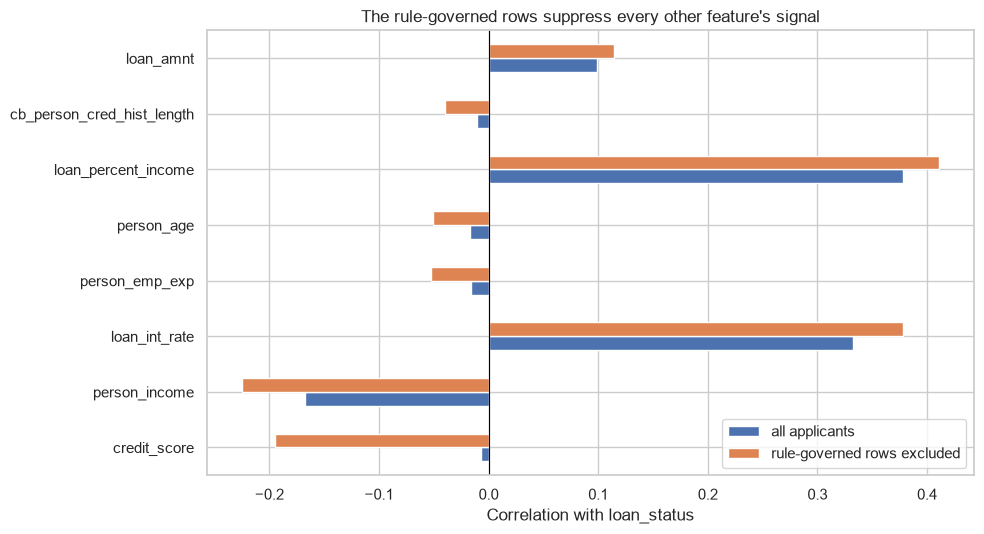

In [171]:
comparison_corr[["all applicants", "rule-governed rows excluded"]].plot(
    kind="barh", figsize=(10, 5.5)
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(f"Correlation with {TARGET}")
plt.title("The rule-governed rows suppress every other feature's signal")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 7.3 The result

**Every single numeric feature became stronger.** None weakened.

The most dramatic change is `credit_score`, which moves from **−0.007 to roughly −0.195** — from apparently irrelevant to a clear relationship, a change of roughly 28×.

This resolves the puzzle from Section 4.9. Credit score was never irrelevant to this dataset. Its signal was being averaged into nothing by 22,776 applicants whose outcome had already been settled by a different field entirely.

Let's confirm that the credit score relationship is a genuine gradient rather than an artifact of a couple of extreme bins.

Approval rate by credit score decile, rule-governed rows excluded:

                  approval_rate     n
credit_score                         
(430.999, 578.0]          0.669  2205
(578.0, 604.0]            0.536  2189
(604.0, 622.0]            0.495  2191
(622.0, 636.0]            0.445  2204
(636.0, 648.0]            0.450  2195
(648.0, 659.0]            0.418  2207
(659.0, 670.0]            0.393  2256
(670.0, 681.0]            0.385  2106
(681.0, 696.0]            0.368  2223
(696.0, 784.0]            0.323  2161


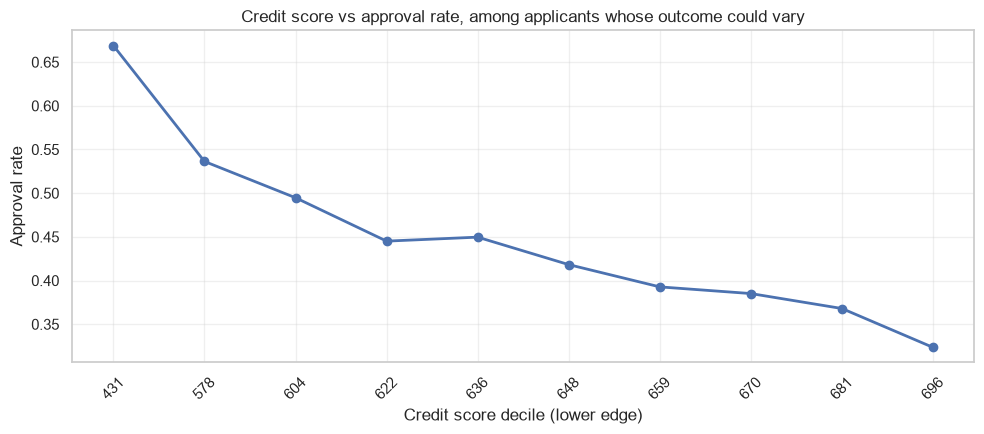

In [172]:
deciles = pd.qcut(free["credit_score"], 10, duplicates="drop")

by_score = free.groupby(deciles, observed=True)[TARGET].agg(["mean", "size"])
by_score.columns = ["approval_rate", "n"]

print("Approval rate by credit score decile, rule-governed rows excluded:\n")
print(by_score.round(3).to_string())

plt.figure(figsize=(10, 4.5))
plt.plot(range(len(by_score)), by_score["approval_rate"], marker="o", linewidth=2)
plt.xticks(range(len(by_score)),
           [f"{iv.left:.0f}" for iv in by_score.index], rotation=45)
plt.xlabel("Credit score decile (lower edge)")
plt.ylabel("Approval rate")
plt.title("Credit score vs approval rate, among applicants whose outcome could vary")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Monotonic across all ten deciles — a steady decline from the lowest score band to the highest. This is a real, orderly relationship, not noise.

The *direction* is inverted relative to real lending, where a better credit score should improve your odds. That is another instance of the pattern identified in Section 4.5, and it is a property of how this dataset was constructed rather than something to correct.

### 7.4 What this means for the design

Three conclusions, and together they point at a specific architecture.

**The prior-default field is policy, not signal.** It should be executed as a condition, not learned as a weight.

**Keeping it inside the model suppresses everything else.** Removing it recovers real signal from every remaining feature — most dramatically credit score.

**The model will never see a prior defaulter in production.** This is the argument that generalises beyond this dataset. If the rule is enforced before the model is called, then every applicant the model ever scores has `prior_default = "No"`. Training it on a population that is 50.9% cases it will never encounter means training under conditions that don't match inference. Restricting training to the non-defaulter population makes the training distribution match the serving distribution.

Section 8 turns this into feature decisions; Section 9 specifies the resulting design.

### 7.5 One caveat, stated plainly

**Treating a prior default as an automatic decline is correct for this dataset. It would not be correct policy for a real lender.**

Real lenders do extend credit to applicants with prior defaults — at higher rates, with lower limits, or against security. A prior default is a powerful negative signal in reality, not an absolute bar.

The rule is justified here for one specific reason: in this data it holds without exception across 22,776 cases, and the system's job is to reproduce *this* decision process. If this dataset were swapped for real lending records, the first thing to re-check would be whether the rule still holds. It almost certainly would not, and the field would belong back in the model as an ordinary feature.

That check belongs in whatever script retrains the model: assert that no approved applicant has a prior default before training, so the build fails loudly rather than silently producing a model whose assumptions no longer hold.

---

## 8. Feature selection

Three features are removed from the model. Each gets its own justification below, because "the metrics improved" is not a reason — removing features because it flatters your numbers is how you end up with a model that looks good and doesn't work.

The three are removed for three different reasons.

### 8.1 `previous_loan_defaults_on_file` — it is a rule

**Evidence:** 0 approvals out of 22,776 applicants, no exceptions (Section 7.1).

**Reason for removal:** a perfect relationship is a policy, not a pattern. The model cannot exceed 100% accuracy on those cases, and including them suppresses every other feature's signal — credit score by a factor of 28 (Section 7.3).

**Where it goes instead:** enforced as a condition before the model is called. It is not discarded from the *system*, only from the *model*. Section 9 specifies this.

**A second, independent reason:** once the rule is enforced upstream, every applicant reaching the model has the value `"No"`. A column with one value carries zero information. Even setting aside the argument above, the feature would be useless in the model by construction.

### 8.2 `person_gender` — no signal, and a protected attribute

**Evidence:** near-zero mean absolute SHAP value (Section 6.5); approval rates of 21.98% for men and 22.02% for women — a gap of four hundredths of a percentage point (Section 4.7).

**Two independent reasons:**

1. **It contributes nothing.** The model was given it and effectively ignored it. Dropping it simplifies the model and the input form at no measurable cost.
2. **It is a protected characteristic.** Using gender in a credit decision is prohibited or heavily restricted in most jurisdictions, and is a reputational liability everywhere. A feature with no upside and real legal downside is an easy decision.

Note the order of reasoning. SHAP told us it was *safe* to drop — that removing it costs nothing. The reason to *want* it gone is the second one. Those are different things and worth keeping distinct: if gender had been highly predictive, the right response would still have been to remove it, and to think hard about what proxy was driving that prediction.

### 8.3 `person_education` — no signal

**Evidence:** near-zero mean absolute SHAP value; approval rate varies by under 2 percentage points across all five education levels.

**Reason:** purely empirical. It adds nothing the model uses, so it adds nothing but a field for the applicant to fill in.

Unlike gender, there is no legal dimension here. If it had been predictive we would have kept it.

### 8.4 The resulting feature set

In [173]:
# ---------------------------------------------------------------------------
# Feature decisions, each with its Section reference
# ---------------------------------------------------------------------------
POLICY_COLUMN = prior_default_col                  # Section 8.1 -- becomes a rule
LOW_VALUE_COLUMNS = ["person_gender",              # Section 8.2 -- no signal + protected
                     "person_education"]           # Section 8.3 -- no signal

EXCLUDED = [POLICY_COLUMN] + LOW_VALUE_COLUMNS

MODEL_FEATURES = [c for c in df_clean.columns if c not in EXCLUDED + [TARGET]]

decisions = pd.DataFrame([
    {"column": POLICY_COLUMN,     "action": "rule (Stage 1)", "reason": "deterministic: 0/22,776 approved"},
    {"column": "person_gender",   "action": "dropped",        "reason": "no signal + protected attribute"},
    {"column": "person_education","action": "dropped",        "reason": "no signal"},
])
print(decisions.to_string(index=False))

print(f"\nOriginal features:  {len(df_clean.columns) - 1}")
print(f"Excluded:           {len(EXCLUDED)}")
print(f"Model features:     {len(MODEL_FEATURES)}\n")

for f in MODEL_FEATURES:
    # pd.api.types is the reliable test. A direct equality check like
    # `df[f].dtype == object` silently fails here, because this pandas
    # reports text columns as 'str' rather than 'object' (see df.info() in
    # Section 2.1). select_dtypes handles it; `==` does not.
    kind = "numeric" if pd.api.types.is_numeric_dtype(df_clean[f]) else "categorical"
    print(f"  {f:<30} {kind}")

                        column         action                           reason
previous_loan_defaults_on_file rule (Stage 1) deterministic: 0/22,776 approved
                 person_gender        dropped  no signal + protected attribute
              person_education        dropped                        no signal

Original features:  13
Excluded:           3
Model features:     10

  person_age                     numeric
  person_income                  numeric
  person_emp_exp                 numeric
  person_home_ownership          categorical
  loan_amnt                      numeric
  loan_intent                    categorical
  loan_int_rate                  numeric
  loan_percent_income            numeric
  cb_person_cred_hist_length     numeric
  credit_score                   numeric


Ten features remain: eight numeric and two categorical (`person_home_ownership` and `loan_intent`).

Every one of them is information available at the point the application is assessed — supplied by the applicant, returned by a credit bureau, or attached to the loan being applied for.

---

## 9. System design

The feature decisions above imply a specific structure. `previous_loan_defaults_on_file` is not being thrown away — it is being moved out of the model and into code that runs first.

That gives two stages:

```
                     Applicant submits form
                               |
                               v
               ┌────────────────────────────────┐
    STAGE 1    │  POLICY GATE                   │
    (a rule)   │  prior default on file?        │
               └────────────────────────────────┘
                      |                   |
                    Yes                   No
                      |                   |
                      v                   v
                  REJECT           ┌─────────────────────────┐
              reason code:         │  STAGE 2                │
              prior_default        │  XGBoost, 10 features   │
              (no model call)      │  + tuned threshold      │
                                   └─────────────────────────┘
                                              |
                                              v
                                     APPROVE / REJECT
                                     + SHAP explanation
```

**Stage 1** handles 50.9% of applicants with a single condition, at 100% accuracy, and returns a reason a person can read.

**Stage 2** is the model, trained only on applicants who pass Stage 1 — which is precisely the population it will encounter in production.

This is not an unusual pattern. In credit risk it is standard and has a name: **knockout rules followed by a scorecard.** Hard policy criteria are applied first; a statistical model then scores whatever survives. Encoding known policy as policy and modelling only the genuine uncertainty is how production decisioning systems are built.

### 9.1 Is hardcoding part of the answer cheating?

A fair objection: *you've written the answer into the code for half the applicants, so of course the system performs well.*

The response has two parts.

**Stage 1 is not a prediction.** It is a policy decision the lender has already made. The model's job was never to rediscover the institution's own rulebook — it is to make the judgement calls the rulebook leaves open. Nothing is being smuggled in; the rule is stated explicitly, its coverage is reported, and its contribution is measured separately.

**The alternative is worse, not better.** Leaving the rule inside the model doesn't remove it from the system — it hides it inside a tree ensemble and then reports the combined accuracy as though the model earned all of it. That is the less honest presentation, not the more honest one.

---

## 10. Preparing data for Stage 2

### 10.1 Split first, then apply the gate

The full cleaned population is split first, and the gate is then applied **within** each split.

Doing it in that order keeps the three gated partitions as clean subsets of one stratified split of the whole dataset, using the same proportions and seed as Section 5.1. The splits are therefore directly comparable with the all-features model trained earlier, and no applicant can land in two partitions.

The model trains and tunes only on the gated portion of train and validation — the population it will actually score.

In [174]:
# Split the FULL population -- this is what the deployed system receives.
train_full, temp_full = train_test_split(
    df_clean, test_size=0.30, random_state=RANDOM_STATE, stratify=df_clean[TARGET]
)
val_full, test_full = train_test_split(
    temp_full, test_size=0.50, random_state=RANDOM_STATE, stratify=temp_full[TARGET]
)

# Apply the Stage 1 rule within each split -- this is what the model receives.
# The rule is one comparison; it is applied directly rather than wrapped,
# because in the deployed system it lives in the application layer, not here.
POLICY_REJECT_VALUE = "Yes"

train_gated = train_full[train_full[POLICY_COLUMN] != POLICY_REJECT_VALUE]
val_gated = val_full[val_full[POLICY_COLUMN] != POLICY_REJECT_VALUE]
test_gated = test_full[test_full[POLICY_COLUMN] != POLICY_REJECT_VALUE]

rows = []
for name, full, gated in [("train", train_full, train_gated),
                          ("validation", val_full, val_gated),
                          ("test", test_full, test_gated)]:
    rows.append({
        "split": name,
        "full rows": len(full),
        "full approval rate": round(full[TARGET].mean(), 4),
        "gated rows": len(gated),
        "gated approval rate": round(gated[TARGET].mean(), 4),
    })

print(pd.DataFrame(rows).to_string(index=False))

     split  full rows  full approval rate  gated rows  gated approval rate
     train      31299              0.2200       15370               0.4481
validation       6707              0.2201        3250               0.4542
      test       6707              0.2199        3317               0.4447


### 10.2 What the gate did to the problem

The approval rate moves from roughly **22% to roughly 45%**. That single number captures why this restructuring matters.

**Before:** a substantially imbalanced problem where a large part of the available signal was one field acting as a switch.

**After:** a nearly balanced problem among applicants whose outcome was genuinely uncertain. Every remaining case is one where a real decision had to be made.

This is a **harder** problem than the one Section 5 solved, and a more meaningful one. Expect the headline metrics to be lower than Section 5's. That is the intended outcome, not a regression — the easy half of the decision has moved into a rule that is right every time, and what remains is the part that actually needed a model.

### 10.3 Preprocessing for Stage 2

One change from Section 5.2: plain one-hot encoding with `remainder="passthrough"` and no scaling.

The reason is deployment. The production pipeline (`src/components/data_transformation.py`) encodes categoricals and passes numerics through untouched. Matching it exactly means the metrics reported here are the metrics the deployed model will produce. Since the final model is tree-based, dropping the scaler costs nothing.

The cell below builds that transformer to show what it produces — which columns are treated as categorical, and how wide the encoded matrix ends up. It is an inspection step, not the pipeline the model uses: `train_stage2` in Section 11.1 constructs the same `ColumnTransformer` internally, so that fitting, threshold selection and evaluation all share one definition. If the two specifications are ever changed apart, this cell is the one that is wrong.

In [175]:
X_train_g = train_gated[MODEL_FEATURES]
y_train_g = train_gated[TARGET]
X_val_g = val_gated[MODEL_FEATURES]
y_val_g = val_gated[TARGET]
X_test_g = test_gated[MODEL_FEATURES]
y_test_g = test_gated[TARGET]

cat_cols_g = X_train_g.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols_g = X_train_g.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical ({len(cat_cols_g)}): {cat_cols_g}")
print(f"Numeric     ({len(num_cols_g)}): {num_cols_g}\n")

preprocessor_g = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_g)],
    remainder="passthrough",
)

_ = preprocessor_g.fit(X_train_g)
print(f"Encoded width: {len(preprocessor_g.get_feature_names_out())} columns")
print(f"Training rows: {len(X_train_g):,}")

Categorical (2): ['person_home_ownership', 'loan_intent']
Numeric     (8): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Encoded width: 18 columns
Training rows: 15,370


---

## 11. Stage 2 — model and threshold

### 11.1 A reusable training function

Training, threshold selection and evaluation are wrapped in a single function rather than written inline. Two reasons.

**It keeps the three data splits from being mixed up.** The function fits on train, selects the threshold on validation, and reports on test — enforcing the methodological rule from the introduction in one place, where it can be read and checked, instead of scattering it across three cells where a slip would be invisible.

**It makes the procedure reusable.** Retraining on a different feature set, a refreshed extract, or a changed policy gate is one call with the same guarantees, rather than a copy-paste that quietly drifts.

In [176]:
def train_stage2(features, label, verbose=True):
    """
    Train XGBoost on the gated training population, select the decision
    threshold on the gated validation set, then report on the gated test set.

    Returns a dict holding the fitted objects, the chosen threshold, and
    test-set metrics.
    """
    X_tr, y_tr = train_gated[features], train_gated[TARGET]
    X_va, y_va = val_gated[features], val_gated[TARGET]
    X_te, y_te = test_gated[features], test_gated[TARGET]

    cat_cols = X_tr.select_dtypes(include=["object", "string"]).columns.tolist()

    prep = ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
        remainder="passthrough",
    )
    X_tr_t = prep.fit_transform(X_tr)
    X_va_t = prep.transform(X_va)
    X_te_t = prep.transform(X_te)

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )
    model.fit(X_tr_t, y_tr)

    # --- Threshold selection: VALIDATION set only -------------------------
    # Each feature set produces a different score distribution, so each model
    # needs its own threshold. Sharing one would rig the comparison.
    va_proba = model.predict_proba(X_va_t)[:, 1]
    prec, rec, thr = precision_recall_curve(y_va, va_proba)
    f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
    threshold = float(thr[int(f1s.argmax())])

    # --- Reporting: TEST set only ----------------------------------------
    te_proba = model.predict_proba(X_te_t)[:, 1]
    te_pred = (te_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, te_pred).ravel()

    result = {
        "label": label,
        "model": model,
        "preprocessor": prep,
        "features": list(features),
        "threshold": threshold,
        "scale_pos_weight": spw,
        "roc_auc": roc_auc_score(y_te, te_proba),
        "precision": precision_score(y_te, te_pred),
        "recall": recall_score(y_te, te_pred),
        "f1": f1_score(y_te, te_pred),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "y_test": y_te, "test_proba": te_proba, "test_pred": te_pred,
        "val_proba": va_proba, "y_val": y_va,
    }

    if verbose:
        print(f"=== {label} ===")
        print(f"Features:            {len(result['features'])}")
        print(f"scale_pos_weight:    {spw:.3f}")
        print(f"Threshold (from val): {threshold:.4f}")
        print(f"ROC-AUC (test):      {result['roc_auc']:.4f}")
        print(f"\nConfusion matrix (test):")
        print(confusion_matrix(y_te, te_pred))
        print(f"\n{classification_report(y_te, te_pred, target_names=['rejected', 'approved'])}")

    return result


print("Training function defined.")

Training function defined.


Note `scale_pos_weight` in the output. On the full population it was around 3.5; on the gated population it is much closer to 1, because the gate removed a large block of rejections along with the rule. Less imbalance left to correct.

### 11.2 The final model

In [177]:
final_model = train_stage2(MODEL_FEATURES, "Stage 2 — 10 features")

=== Stage 2 — 10 features ===
Features:            10
scale_pos_weight:    1.232
Threshold (from val): 0.4914
ROC-AUC (test):      0.9264

Confusion matrix (test):
[[1632  210]
 [ 291 1184]]

              precision    recall  f1-score   support

    rejected       0.85      0.89      0.87      1842
    approved       0.85      0.80      0.83      1475

    accuracy                           0.85      3317
   macro avg       0.85      0.84      0.85      3317
weighted avg       0.85      0.85      0.85      3317



**ROC-AUC 0.9264 on the gated test set**, against 0.9761 for the all-features model in Section 5.6. Lower, and expected to be — Section 10.2 said so in advance. The earlier figure was partly measuring the model's ability to read one flag; this one is measured only on applicants whose outcome was genuinely in doubt.

The rest of the report is worth reading rather than skimming:

- **Precision and recall are balanced** (0.85 / 0.80 on the approved class). Neither class is being sacrificed for the other, which is what the near-1.0 `scale_pos_weight` and the tuned threshold together are for.
- **210 false positives against 291 false negatives.** Roughly comparable counts — which, given that a bad approval costs far more than a lost customer, is *not* the balance a lender would want. That is the threshold's doing, and 11.3 takes it up.

### 11.3 Why the threshold is not 0.5

`predict()` approves anything scoring above 0.5. Nothing justifies that number. It implicitly asserts that a false positive and a false negative cost the same, and in lending they do not:

- **False positive** — approving someone who shouldn't be. Potential loss of the entire principal.
- **False negative** — rejecting someone creditworthy. Loss of the interest margin you would have earned.

The first is roughly an order of magnitude more expensive. If that asymmetry is taken seriously, the threshold should sit **above** 0.5 — approve more cautiously than a coin flip — and how far above is a business question rather than a statistical one.

Three ways of framing that question, all computed on the validation set. They do not agree with each other, and 11.4 confronts why.

In [178]:
# Framing 1: precision and recall across the whole threshold range.
val_proba = final_model["val_proba"]
y_va = final_model["y_val"]

rows = []
for t in np.arange(0.10, 0.96, 0.05):
    preds = (val_proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_va, preds, zero_division=0), 3),
        "recall": round(recall_score(y_va, preds), 3),
        "F1": round(f1_score(y_va, preds), 3),
        "approvals": int(preds.sum()),
    })

threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

 threshold  precision  recall    F1  approvals
      0.10      0.561   0.988 0.716       2601
      0.15      0.605   0.970 0.746       2365
      0.20      0.649   0.947 0.770       2154
      0.25      0.702   0.931 0.801       1956
      0.30      0.745   0.917 0.822       1817
      0.35      0.780   0.888 0.831       1681
      0.40      0.814   0.855 0.834       1551
      0.45      0.843   0.827 0.835       1448
      0.50      0.871   0.803 0.836       1360
      0.55      0.890   0.781 0.832       1295
      0.60      0.912   0.761 0.830       1231
      0.65      0.932   0.741 0.825       1173
      0.70      0.941   0.716 0.813       1123
      0.75      0.952   0.692 0.802       1074
      0.80      0.966   0.656 0.781       1002
      0.85      0.982   0.623 0.762        936
      0.90      0.990   0.565 0.720        842
      0.95      0.999   0.478 0.646        706


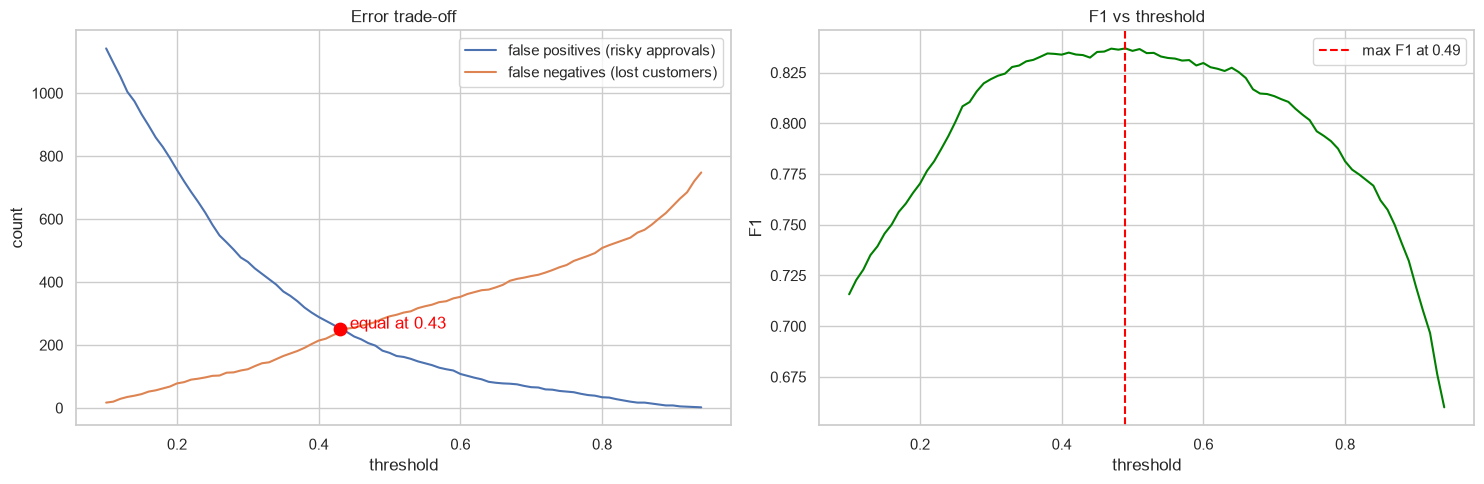

Equal-error threshold: 0.43  (FP=252, FN=241)
Max-F1 threshold:      0.49


In [179]:
# Framing 2: where do the two error types cross?
fine = np.arange(0.10, 0.95, 0.01)
fp_list, fn_list, f1_list = [], [], []

for t in fine:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_va, preds).ravel()
    fp_list.append(fp)
    fn_list.append(fn)
    f1_list.append(f1_score(y_va, preds))

balance_idx = int(np.argmin(np.abs(np.array(fp_list) - np.array(fn_list))))
balance_t = fine[balance_idx]
best_f1_idx = int(np.argmax(f1_list))
best_f1_t = fine[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(fine, fp_list, label="false positives (risky approvals)")
axes[0].plot(fine, fn_list, label="false negatives (lost customers)")
axes[0].scatter(balance_t, fp_list[balance_idx], color="red", s=80, zorder=5)
axes[0].annotate(f"  equal at {balance_t:.2f}",
                 (balance_t, fp_list[balance_idx]), color="red")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("count")
axes[0].set_title("Error trade-off")
axes[0].legend()

axes[1].plot(fine, f1_list, color="green")
axes[1].axvline(best_f1_t, color="red", linestyle="--",
                label=f"max F1 at {best_f1_t:.2f}")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs threshold")
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Equal-error threshold: {balance_t:.2f}  "
      f"(FP={fp_list[balance_idx]}, FN={fn_list[balance_idx]})")
print(f"Max-F1 threshold:      {best_f1_t:.2f}")

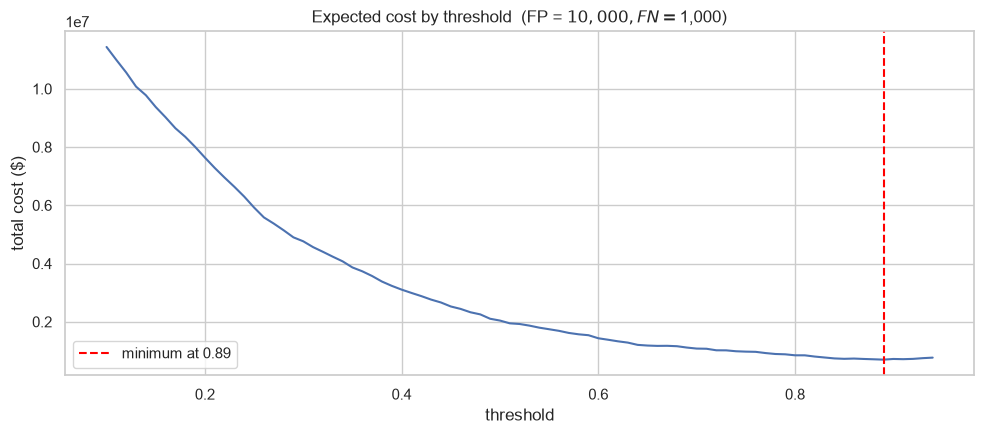

Ten cheapest thresholds:
 threshold  FP  FN  total_cost
      0.89   8 619      699000
      0.88  11 601      711000
      0.91   5 665      715000
      0.87  14 582      722000
      0.90   8 642      722000
      0.92   4 685      725000
      0.85  17 557      727000
      0.86  17 566      736000
      0.84  20 541      741000
      0.93   3 720      750000


In [180]:
# Framing 3: assign costs and minimise them.
COST_FP = 10_000   # approving a bad applicant -- lose the principal
COST_FN = 1_000    # rejecting a good applicant -- lose the margin

cost_rows = []
for t in fine:
    preds = (val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_va, preds).ravel()
    cost_rows.append({"threshold": round(t, 2), "FP": fp, "FN": fn,
                      "total_cost": fp * COST_FP + fn * COST_FN})

cost_df = pd.DataFrame(cost_rows)
cost_t = cost_df.loc[cost_df["total_cost"].idxmin(), "threshold"]

plt.figure(figsize=(10, 4.5))
plt.plot(cost_df["threshold"], cost_df["total_cost"])
plt.axvline(cost_t, color="red", linestyle="--", label=f"minimum at {cost_t:.2f}")
plt.xlabel("threshold"); plt.ylabel("total cost ($)")
plt.title(f"Expected cost by threshold  (FP = ${COST_FP:,}, FN = ${COST_FN:,})")
plt.legend(); plt.tight_layout(); plt.show()

print("Ten cheapest thresholds:")
print(cost_df.sort_values("total_cost").head(10).to_string(index=False))

### 11.4 Which threshold, and what the cost figures mean

The dollar amounts above are **illustrative, not derived**. A real lender would calculate them from average loan size, recovery rates on defaults, and net interest margin. The point of the exercise is the method: once you state the relative costs, the threshold follows mechanically instead of being a matter of taste.

Three defensible answers, depending on what the business is optimising:

| Framing | Behaviour |
|---|---|
| **Cost-minimising** | Most conservative. Fewest bad approvals, turns away the most good applicants. Appropriate when capital preservation dominates. |
| **Equal-error** | Treats both mistakes as equally costly. A neutral reference point. |
| **Maximum F1** | Best balance of precision and recall as a single number. A reasonable default when no real cost figures exist. |

### The three framings disagree, and that matters

Look at where each one actually lands:

| Framing | Threshold | Consequence |
|---|---|---|
| Cost-minimising (10:1) | **~0.89** | 8 bad approvals against 619 rejected good applicants |
| Equal-error (FP = FN) | **~0.43** | Both mistakes equally numerous (252 against 241) |
| Maximum F1 | **~0.49** | Best precision/recall balance |

**The cost-minimising answer is nowhere near the other two.** That is not a bug — it is what a 10:1 cost ratio actually implies. When one error is ten times more expensive, the arithmetic says be extremely conservative and accept turning away good business.

**And note the tension with 11.3.** That section argued the threshold should sit meaningfully *above* 0.5. Maximum F1 puts it at 0.49 — effectively at the coin flip 11.3 rejected. The near-coincidence is not reassurance, and the reason is worth naming rather than glossing over: **maximising F1 weights precision and recall equally, which is the same as assuming both errors cost the same.** It quietly discards the cost asymmetry that 11.3 spent five lines establishing, and lands next to 0.5 by construction rather than by argument.

So which ships, and why:

**This notebook uses the maximum-F1 threshold** — but as a *placeholder*, not as the right answer. The reason is that the cost figures in 11.3 were invented for illustration. Optimising against made-up costs would produce a confidently wrong threshold; maximising F1 at least produces a balanced one, and makes no claim about economics it cannot support.

**What should happen before deployment:** obtain real figures for average loan size, recovery rate on default, and net interest margin, then re-derive the threshold from the cost curve. That will almost certainly move it upward, and it is a change that requires **no retraining** — the threshold is a lever, not a model parameter. It is the cheapest control the system has, and the one most likely to be set wrongly by default.

---

## 12. Explaining the final model

The same SHAP analysis as Section 6, now on the ten-feature model that will actually ship. Worth repeating rather than assuming, because the feature set changed substantially and so will the explanations.

In [181]:
X_val_g_t = final_model["preprocessor"].transform(X_val_g)
names_g = final_model["preprocessor"].get_feature_names_out()

X_val_g_shap = pd.DataFrame(
    X_val_g_t.toarray() if sp.issparse(X_val_g_t) else X_val_g_t,
    columns=names_g,
)

explainer_g = shap.TreeExplainer(final_model["model"])
shap_values_g = explainer_g(X_val_g_shap)

print(f"SHAP values for {X_val_g_shap.shape[0]:,} applicants, "
      f"{X_val_g_shap.shape[1]} encoded features.")

SHAP values for 3,250 applicants, 18 encoded features.


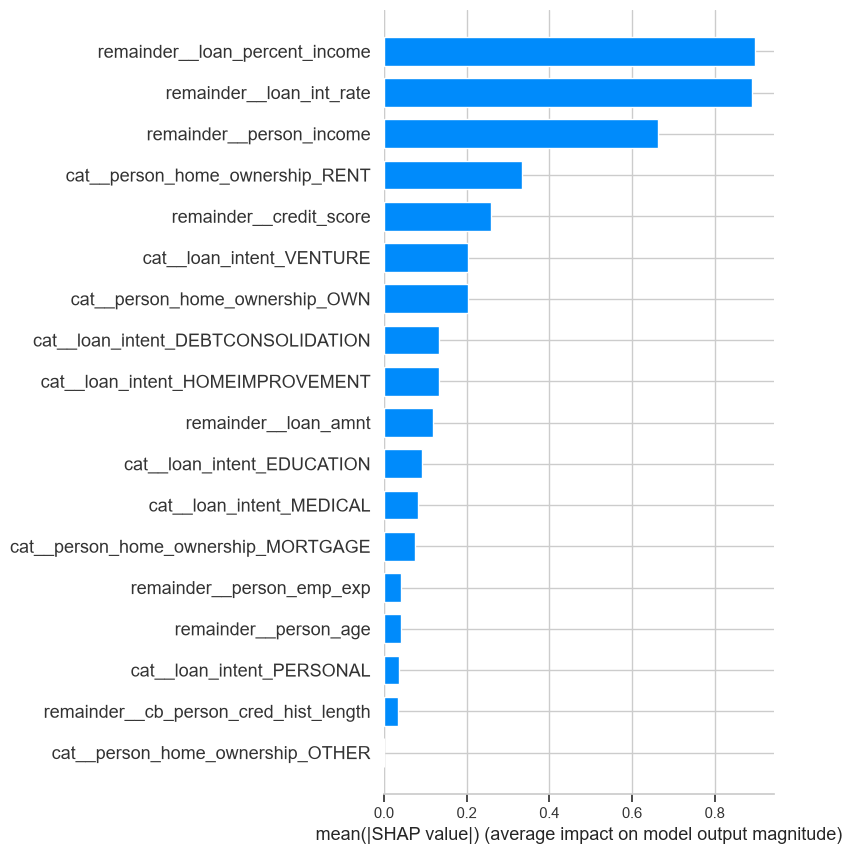

In [182]:
shap.summary_plot(shap_values_g, X_val_g_shap, plot_type="bar", show=True)

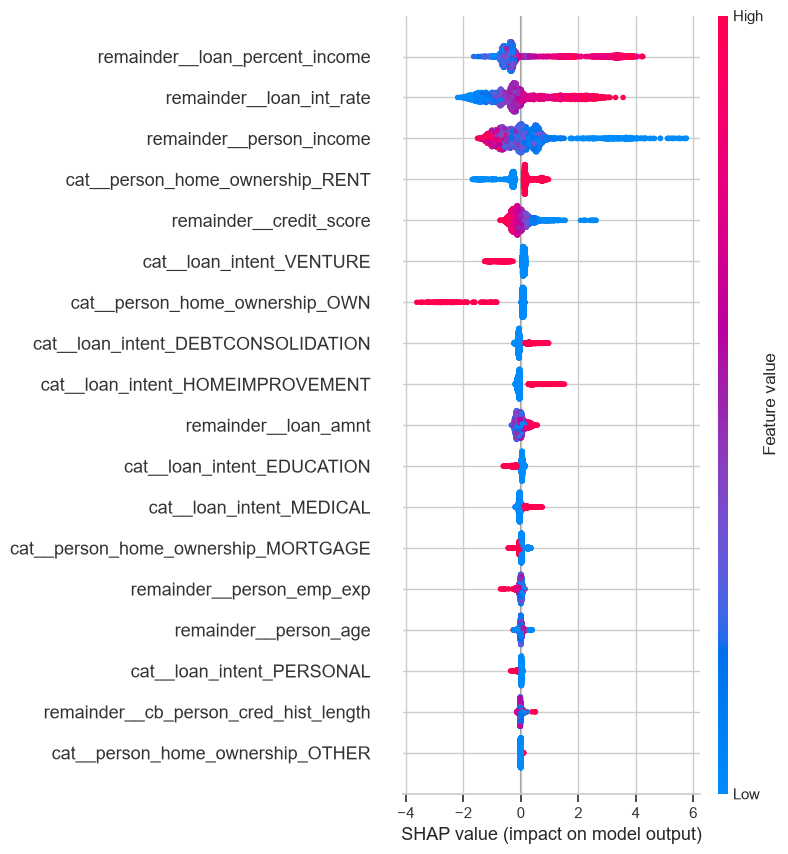

In [183]:
shap.summary_plot(shap_values_g, X_val_g_shap, show=True)

In [184]:
mean_abs_g = np.abs(shap_values_g.values).mean(axis=0)

importance_g = (pd.DataFrame({"encoded_feature": names_g,
                              "mean_abs_shap": mean_abs_g})
                .sort_values("mean_abs_shap", ascending=False)
                .reset_index(drop=True))
importance_g["share"] = (importance_g["mean_abs_shap"] /
                         importance_g["mean_abs_shap"].sum()).round(4)

print("Final model — feature importance:\n")
print(importance_g.to_string(index=False))

Final model — feature importance:

                      encoded_feature  mean_abs_shap  share
       remainder__loan_percent_income       0.898671 0.2119
             remainder__loan_int_rate       0.889498 0.2098
             remainder__person_income       0.662014 0.1561
      cat__person_home_ownership_RENT       0.334235 0.0788
              remainder__credit_score       0.259976 0.0613
             cat__loan_intent_VENTURE       0.203699 0.0480
       cat__person_home_ownership_OWN       0.203690 0.0480
   cat__loan_intent_DEBTCONSOLIDATION       0.134538 0.0317
     cat__loan_intent_HOMEIMPROVEMENT       0.132808 0.0313
                 remainder__loan_amnt       0.118063 0.0278
           cat__loan_intent_EDUCATION       0.091210 0.0215
             cat__loan_intent_MEDICAL       0.082303 0.0194
  cat__person_home_ownership_MORTGAGE       0.075832 0.0179
            remainder__person_emp_exp       0.042091 0.0099
                remainder__person_age       0.041140 0.0097
     

### 12.1 How this differs from the first model

Compare the ranking above with the one in Section 6.5 and two changes stand out.

**The prior-default column is gone**, so the importance that was concentrated there is now distributed across features that genuinely vary between applicants. Nothing dominates the way it did before.

**`credit_score` climbs.** In the first model it accounted for roughly 3% of total explanatory weight, seventh in the ranking — modest for the feature most designed to summarise creditworthiness. Here it is around 6% and fifth. Its relative importance roughly doubled, which is the suppression effect from Section 7.3 showing up in the explanations as well as in the correlations. With the rule-governed rows out of the training set, the model can finally use it.

There is also a practical benefit for the explanation layer that is easy to overlook. Every applicant who reaches Stage 2 has `prior_default = "No"` — it is constant across all of them. Had the feature stayed in the model, it would have contributed the *same* push to every single explanation a user ever saw: identical clutter in an interface whose job is to tell people something specific about their own application.



---

## 13. Summary

### What was built

A two-stage loan approval system:

- **Stage 1** — a deterministic policy gate handling 50.9% of applicants at 100% accuracy, returning a plain-language reason.
- **Stage 2** — an XGBoost classifier over ten features with a validation-tuned decision threshold, plus a SHAP layer that explains individual declines.

### Every decision, and its justification

| Decision | Why |
|---|---|
| Removed 6 records with impossible ages | Age 144, employment 124 years — corrupted rows (3.3) |
| Accuracy rejected as a metric | 78% of applications are rejections; a reject-everything model scores 78% (4.1) |
| Class weighting during training | Corrects the model's drift toward the majority class (5.3) |
| `previous_loan_defaults_on_file` → Stage 1 rule | 0 approvals in 22,776. A rule, not a signal. A model cannot beat 100% (8.1, 9.1) |
| Dropped `person_gender` | No SHAP contribution, and a protected attribute (8.2) |
| Dropped `person_education` | No SHAP contribution (8.3) |
| Model trained only on gated applicants | The only population it will ever score in production (7.4) |
| XGBoost over LR and RF | Highest ROC-AUC; cross-validation confirmed the score is stable (5.6, 5.7) |
| Threshold tuned rather than left at 0.5 | 0.5 is an arbitrary cutoff. The shipped value maximises F1 and is a **placeholder** — it does not encode the cost asymmetry, and should be re-derived from real loan economics before deployment (11.4) |
| Threshold tuned on validation, reported on test | Tuning on test and reporting the same figure is leakage |

### The finding that shaped the design

The investigation began with a bar chart showing a 0% approval rate for one category, and ended by restructuring the system.

Checking whether that field was a statistical tendency or a rule turned up **zero exceptions in 22,776 applicants** — an authored rule, not a learned relationship. That had a second-order consequence which was easy to miss: those rows are over half the dataset with a predetermined outcome, and pooling across them had flattened every correlation computed on the full data.

Recomputing on only the applicants whose outcome could vary showed **every numeric feature strengthening**, most dramatically `credit_score`, which moved from −0.007 to roughly −0.195 and turned out to be monotonic across all ten deciles. A textbook Simpson's paradox hiding behind one categorical column.

That drove the architecture: the rule became Stage 1, the model was retrained on the population it will actually see, and the two stages are measured separately so neither borrows credit from the other.

### Known limitations

- **The dataset's internal logic is not real lending logic.** High debt-to-income and low income both associate with *approval*, better credit scores associate with *rejection*, and the interest rate ignores every risk marker in the data (4.5, 4.9). The model learns these relationships correctly because they are genuinely present — but it means these metrics describe this dataset, not how a model would perform on real applications.
- **The dataset is synthetic.** No missing values across all 44,719 rows, no duplicates, and at least one hard-coded rule visible in it.
- **The Stage 1 rule is dataset-specific.** Real lenders price prior defaults rather than auto-declining (7.5). Before retraining on any new data, the rule should be re-checked for exceptions.
- **Stage 1 metrics are structural, not earned.** 100% accuracy on rows selected by the property that defines them.
- **No fairness audit.** Gender was dropped, but proxies may remain — home ownership and income both correlate with demographics in reality. A production credit model would require disparate-impact testing.
- **No calibration check.** ROC-AUC measures ranking, not whether a predicted 70% means 70%. If the probability is shown to users, it should be calibrated first.
- **Cost figures in 11.3 are illustrative**, not derived from real loan economics.

### Next steps

1. Add calibration (`CalibratedClassifierCV` or isotonic regression) if the displayed probability is to be read literally.
2. Fairness audit across income and home-ownership groups.
3. Revisit the Stage 1 rule against any new data before retraining — it is only valid while it holds without exception.

---

### Final verdict

**Deploying the two-stage system: policy gate, then a ten-feature model with a validation-tuned threshold.**

`previous_loan_defaults_on_file` predicts rejection perfectly across 22,776 applicants, which makes it policy rather than signal. Encoding it as a rule gets those cases right every time, gives them a reason in plain language instead of a SHAP chart, and — the consequence that actually mattered — stops it suppressing every other feature in the dataset.

| | |
|---|---|
| **Stage 1** | Rule — prior default on file → reject, reason `prior_default_on_file`. 50.9% of applicants, 100% accurate |
| **Stage 2** | XGBoost — `max_depth=4`, `n_estimators=300`, `learning_rate=0.05`, `scale_pos_weight` from the gated split |
| **Features** | 10 — the original 13 minus the policy column, gender and education |
| **Threshold** | Selected on validation for maximum F1, reported on test (11.2). A placeholder pending real cost figures — see 11.4 |

**On the headline number.** Stage 2's ROC-AUC is lower than the all-features model in Section 5, and that is the intended result. The easy half of the problem moved into a rule that never errs; what remains is a near-balanced decision among applicants whose outcome was genuinely uncertain. The higher number was higher partly because it measured the model's ability to read one flag.